# Introduction
This project is part of a series of projects that aim to be my personal path to becoming an AI engineer. I'm currently studying data science engineering and have a professional data science certificate. This is the second part of the San Jose climate and crime study. The first part was just a one-point test of the relationship between rainfall and crime in buildings. This one aims to be more comprehensive by including all other crime victims.

# Data collect
In this section, I reviewed a larger number of crime statistics by year, from 2015 to 2025. These were taken from the OIJ government website, and were free and open to use. For the climate section, a website with historical data was used.

URl:

https://www.historique-meteo.net/amerique-centrale/costa-rica/san-jose/

https://sitiooij.poder-judicial.go.cr/index.php/apertura/transparencia/estadisticas-policiales

# ETL Data Processing
The goal is to combine all the information into a robust dataset. Since the data was downloaded by year, which is how the two pages handle the data, it will be merged and cleaned separately for the years 2020 to 2025, and a date-based merge will be used.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib as mp
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import shapiro
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt


In [ ]:
# Leer el archivo
df_crime_2015 = pd.read_csv('/content/sample_data/Estadisticas 2015.csv', on_bad_lines='warn')
display(df_crime_2015.head())

/tmp/ipython-input-4178460026.py:2: ParserWarning: Skipping line 13376: expected 12 fields, saw 13
Skipping line 45561: expected 12 fields, saw 13

  df_crime_2015 = pd.read_csv('/content/sample_data/Estadisticas 2015.csv', on_bad_lines='warn')


,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,ALAJUELA,UPALA,NaN
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,BUENOS AIRES,NaN
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,SAN JOSE,SAN JOSE,NaN
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,CARTAGO,LA UNION,NaN


In [ ]:
# Leer el archivo
df_crime_2016 = pd.read_csv('/content/sample_data/Estadisticas 2016.csv', on_bad_lines='warn')
display(df_crime_2016.head())

/tmp/ipython-input-1965374471.py:2: ParserWarning: Skipping line 739: expected 12 fields, saw 13
Skipping line 1293: expected 12 fields, saw 13
Skipping line 22875: expected 12 fields, saw 13
Skipping line 24138: expected 12 fields, saw 13
Skipping line 25320: expected 12 fields, saw 13
Skipping line 27607: expected 12 fields, saw 13
Skipping line 59074: expected 12 fields, saw 13

  df_crime_2016 = pd.read_csv('/content/sample_data/Estadisticas 2016.csv', on_bad_lines='warn')


,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2016-01-01,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,GOICOECHEA,NaN
1,ASALTO,ARMA BLANCA,2016-01-06,15:00:00 - 17:59:59,PERSONA,CLIENTE LOCAL COMERCIAL [PERSONA],Menor de edad,MUJER,COSTA RICA,HEREDIA,SANTA BARBARA,NaN
2,ASALTO,ARMA BLANCA,2016-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,GUANACASTE,CANAS,NaN
3,ASALTO,ARMA BLANCA,2016-01-11,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN
4,ASALTO,ARMA BLANCA,2016-01-13,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Menor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN


In [ ]:
# Leer el archivo
df_crime_2017 = pd.read_csv('/content/sample_data/Estadisticas 2017.csv', on_bad_lines='warn')
display(df_crime_2017.head())

/tmp/ipython-input-2572678662.py:2: ParserWarning: Skipping line 11184: expected 12 fields, saw 13
Skipping line 20571: expected 12 fields, saw 13
Skipping line 21514: expected 12 fields, saw 13

  df_crime_2017 = pd.read_csv('/content/sample_data/Estadisticas 2017.csv', on_bad_lines='warn')


,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2017-01-01,18:00:00 - 20:59:59,PERSONA,OTRO O INDETERMINADO [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN
1,ASALTO,ARMA BLANCA,2017-01-02,12:00:00 - 14:59:59,PERSONA,MENOR DE EDAD [PERSONA],Menor de edad,HOMBRE,COSTA RICA,ALAJUELA,GRECIA,NaN
2,ASALTO,ARMA BLANCA,2017-01-02,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,HEREDIA,HEREDIA,NaN
3,ASALTO,ARMA BLANCA,2017-01-02,00:00:00 - 02:59:59,VIVIENDA,NO APLICA [VIVIENDA],Menor de edad,HOMBRE,Desconocido,LIMON,MATINA,NaN
4,ASALTO,ARMA BLANCA,2017-01-03,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,DESAMPARADOS,NaN


In [ ]:
# Leer el archivo
df_crime_2018 = pd.read_csv('/content/sample_data/Estadisticas 2018.csv', on_bad_lines='warn')
display(df_crime_2018.head())

,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2018-01-01,00:00:00 - 02:59:59,PERSONA,GUARDA [PERSONA],Mayor de edad,HOMBRE,NICARAGUA,ALAJUELA,SAN CARLOS,NaN
1,ASALTO,ARMA BLANCA,2018-01-03,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Menor de edad,MUJER,COSTA RICA,HEREDIA,BELEN,NaN
2,ASALTO,ARMA BLANCA,2018-01-07,15:00:00 - 17:59:59,PERSONA,SIN CLASIFICAR [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,PUNTARENAS,NaN
3,ASALTO,ARMA BLANCA,2018-01-10,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Adulto Mayor,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN
4,ASALTO,ARMA BLANCA,2018-01-12,00:00:00 - 02:59:59,PERSONA,TAXISTA [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,CORREDORES,NaN


In [ ]:
# Leer el archivo
df_crime_2019 = pd.read_csv('/content/sample_data/Estadisticas 2019.csv', on_bad_lines='warn')
display(df_crime_2019.head())

,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2019-01-01,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,ESCAZU,NaN
1,ASALTO,ARMA BLANCA,2019-01-06,18:00:00 - 20:59:59,PERSONA,OTRO O INDETERMINADO [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN
2,ASALTO,ARMA BLANCA,2019-01-07,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,SAN JOSE,SAN JOSE,NaN
3,ASALTO,ARMA BLANCA,2019-01-11,09:00:00 - 11:59:59,VEHICULO,SERVICIO PUBLICO/TAXI LEGAL O PIRATA/AUTOBUS [...,Mayor de edad,HOMBRE,COSTA RICA,ALAJUELA,ALAJUELA,NaN
4,ASALTO,ARMA BLANCA,2019-01-14,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,TIBAS,NaN


In [ ]:
# Leer el archivo
df_crime_2020 = pd.read_csv('/content/sample_data/Estadisticas 2020.csv', on_bad_lines='warn')
display(df_crime_2020.head())

,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2020-01-05,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,SAN JOSE,SAN JOSE,NaN
1,ASALTO,ARMA BLANCA,2020-01-05,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Menor de edad,HOMBRE,COSTA RICA,HEREDIA,SANTA BARBARA,NaN
2,ASALTO,ARMA BLANCA,2020-01-05,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,ALAJUELA,SAN CARLOS,NaN
3,ASALTO,ARMA BLANCA,2020-01-06,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,NICARAGUA,SAN JOSE,SAN JOSE,NaN
4,ASALTO,ARMA BLANCA,2020-01-05,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,SAN JOSE,SAN JOSE,NaN


In [ ]:
# Leer el archivo
df_crime_2021 = pd.read_csv('/content/sample_data/Estadisticas 2021.csv', on_bad_lines='warn')
display(df_crime_2021.head())

/tmp/ipython-input-518107770.py:2: ParserWarning: Skipping line 9937: expected 12 fields, saw 13
Skipping line 13418: expected 12 fields, saw 13
Skipping line 25394: expected 12 fields, saw 13

  df_crime_2021 = pd.read_csv('/content/sample_data/Estadisticas 2021.csv', on_bad_lines='warn')


,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2021-01-02,09:00:00 - 11:59:59,PERSONA,OTRO O INDETERMINADO [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,GOICOECHEA,NaN
1,ASALTO,ARMA BLANCA,2021-01-02,03:00:00 - 05:59:59,PERSONA,OTRO O INDETERMINADO [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,CARTAGO,TURRIALBA,NaN
2,ASALTO,ARMA BLANCA,2021-01-06,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,SAN JOSE,CURRIDABAT,NaN
3,ASALTO,ARMA BLANCA,2021-01-06,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Menor de edad,MUJER,COSTA RICA,SAN JOSE,CURRIDABAT,NaN
4,ASALTO,ARMA BLANCA,2021-01-07,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Menor de edad,MUJER,COSTA RICA,SAN JOSE,SAN JOSE,NaN


In [ ]:
# Leer el archivo
df_crime_2022 = pd.read_csv('/content/sample_data/Estadisticas 2022.csv', on_bad_lines='warn')
display(df_crime_2022.head())

/tmp/ipython-input-3612116278.py:2: ParserWarning: Skipping line 12216: expected 12 fields, saw 13
Skipping line 19696: expected 12 fields, saw 13

  df_crime_2022 = pd.read_csv('/content/sample_data/Estadisticas 2022.csv', on_bad_lines='warn')


,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2022-01-02,18:00:00 - 20:59:59,PERSONA,OTRO O INDETERMINADO [PERSONA],Desconocido,HOMBRE,COSTA RICA,LIMON,GUACIMO,NaN
1,ASALTO,ARMA BLANCA,2022-01-06,00:00:00 - 02:59:59,VEHICULO,MOTOCICLETA/REPARTIDOR [VEHICULO],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN
2,ASALTO,ARMA BLANCA,2022-01-09,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN
3,ASALTO,ARMA BLANCA,2022-01-07,21:00:00 - 23:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN
4,ASALTO,ARMA BLANCA,2022-01-14,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,PEREZ ZELEDON,NaN


In [ ]:
# Leer el archivo
df_crime_2023 = pd.read_csv('/content/sample_data/Estadisticas 2023.csv', on_bad_lines='warn')
display(df_crime_2023.head())

/tmp/ipython-input-3213863174.py:2: ParserWarning: Skipping line 5126: expected 12 fields, saw 13
Skipping line 22951: expected 12 fields, saw 13

  df_crime_2023 = pd.read_csv('/content/sample_data/Estadisticas 2023.csv', on_bad_lines='warn')


,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2023-01-02,12:00:00 - 14:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,BUENOS AIRES,NaN
1,ASALTO,ARMA BLANCA,2023-01-04,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,ESTADOS UNIDOS,LIMON,TALAMANCA,NaN
2,ASALTO,ARMA BLANCA,2023-01-05,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,PUNTARENAS,NaN
3,ASALTO,ARMA BLANCA,2023-01-05,09:00:00 - 11:59:59,PERSONA,PEATON [PERSONA],Desconocido,MUJER,COSTA RICA,SAN JOSE,ALAJUELITA,NaN
4,ASALTO,ARMA BLANCA,2023-01-06,15:00:00 - 17:59:59,VIVIENDA,NO APLICA [VIVIENDA],Adulto Mayor,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN


In [ ]:
# Leer el archivo
df_crime_2024 = pd.read_csv('/content/sample_data/Estadisticas 2024.csv', on_bad_lines='warn')
display(df_crime_2024.head())

/tmp/ipython-input-2065662660.py:2: ParserWarning: Skipping line 30772: expected 12 fields, saw 13

  df_crime_2024 = pd.read_csv('/content/sample_data/Estadisticas 2024.csv', on_bad_lines='warn')


,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2024-01-01,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,ALAJUELITA,NaN
1,ASALTO,ARMA BLANCA,2024-01-05,15:00:00 - 17:59:59,VIVIENDA,NO APLICA [VIVIENDA],Mayor de edad,MUJER,COSTA RICA,GUANACASTE,LIBERIA,NaN
2,ASALTO,ARMA BLANCA,2024-01-06,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,NICARAGUA,SAN JOSE,SAN JOSE,NaN
3,ASALTO,ARMA BLANCA,2024-01-07,03:00:00 - 05:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN
4,ASALTO,ARMA BLANCA,2024-01-03,21:00:00 - 23:59:59,PERSONA,PEATON [PERSONA],Adulto Mayor,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE,NaN


In [ ]:
# Leer el archivo
df_crime_2025 = pd.read_csv('/content/sample_data/Estadisticas 2025.csv', on_bad_lines='warn')
display(df_crime_2025.head())

/tmp/ipython-input-2867107734.py:2: ParserWarning: Skipping line 5905: expected 12 fields, saw 13

  df_crime_2025 = pd.read_csv('/content/sample_data/Estadisticas 2025.csv', on_bad_lines='warn')


,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito,Unnamed: 11
0,ASALTO,ARMA BLANCA,2025-01-13,21:00:00 - 23:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,HEREDIA,HEREDIA,NaN
1,ASALTO,ARMA BLANCA,2025-01-06,21:00:00 - 23:59:59,EDIFICACION,RESTAURANTE/SODA [EDIFICACION],Desconocido,DESCONOCIDO,Desconocido,SAN JOSE,SAN JOSE,NaN
2,ASALTO,ARMA BLANCA,2025-01-15,18:00:00 - 20:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,LIMON,TALAMANCA,NaN
3,ASALTO,ARMA BLANCA,2025-01-17,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,CARTAGO,CARTAGO,NaN
4,ASALTO,ARMA BLANCA,2025-01-19,00:00:00 - 02:59:59,PERSONA,CLIENTE LOCAL COMERCIAL [PERSONA],Mayor de edad,MUJER,COSTA RICA,SAN JOSE,SAN JOSE,NaN


In [ ]:
# Lista de todos los DataFrames
dfs = [
    df_crime_2015, df_crime_2016, df_crime_2017, df_crime_2018, df_crime_2019,
    df_crime_2020, df_crime_2021, df_crime_2022, df_crime_2023, df_crime_2024,
    df_crime_2025
]

# Concatenar todos en uno solo
df_crime_all = pd.concat(dfs, ignore_index=True)

In [ ]:
df_crime_all = df_crime_all.drop(columns=['Unnamed: 11'], errors='ignore')

In [ ]:
df_crime_all.drop_duplicates(inplace=True)

In [ ]:
display(df_crime_all.head())

,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,ALAJUELA,UPALA
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,BUENOS AIRES
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,CARTAGO,LA UNION


In [ ]:
print(df_crime_all.dtypes)

Delito          object
SubDelito       object
Fecha           object
Victima         object
SubVictima      object
Edad            object
Sexo            object
Nacionalidad    object
Provincia       object
Canton          object
Distrito        object
dtype: object


In [ ]:
df_crime_all.to_csv('df_crime_all_2015_2025.csv', index=False)


In [ ]:
df_crime_clean = df_crime_all.copy()

In [ ]:
display(df_crime_clean.head())

,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,ALAJUELA,UPALA
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,BUENOS AIRES
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,CARTAGO,LA UNION


In [ ]:
selected_columns = [
    'Delito', 'SubDelito', 'Victima', 'SubVictima', 'Edad',
    'Sexo', 'Nacionalidad', 'Provincia', 'Canton', 'Distrito'
]

missing_values = df_crime_clean[selected_columns].isnull().sum()
missing_percentage = (df_crime_clean[selected_columns].isnull().mean() * 100).round(2)

print("🔎 Valores faltantes por columna:")
print(missing_values)

print("\n📉 Porcentaje de valores faltantes:")
print(missing_percentage)

🔎 Valores faltantes por columna:
Delito          0
SubDelito       0
Victima         0
SubVictima      0
Edad            0
Sexo            0
Nacionalidad    0
Provincia       0
Canton          0
Distrito        0
dtype: int64

📉 Porcentaje de valores faltantes:
Delito          0.0
SubDelito       0.0
Victima         0.0
SubVictima      0.0
Edad            0.0
Sexo            0.0
Nacionalidad    0.0
Provincia       0.0
Canton          0.0
Distrito        0.0
dtype: float64


In [ ]:
df_crime_clean.to_csv('df_crime_clean_2015_2025.csv', index=False)

In [ ]:
display(df_crime_clean.head())

,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,ALAJUELA,UPALA
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,BUENOS AIRES
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,CARTAGO,LA UNION


In [ ]:
total_filas = df_crime_clean.shape[0]
print(f"🔢 Total de filas en el corpus: {total_filas}")

🔢 Total de filas en el corpus: 530112


# ETL weather

In [ ]:
df_weather_sanjose_2009_2025 = pd.read_csv('/content/sample_data/export-san-jose0 (1).csv', skiprows=3)
display(df_weather_sanjose_2009_2025.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,20,15,13,15,20,18,1.1,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,25,15,9,15,25,18,1.0,96,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,24,15,11,15,24,19,0.4,88,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,25,15,11,15,25,18,2.7,96,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,24,16,13,16,24,18,8.0,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Asumiendo que 'df_weather_sanjose_2009_2025' es tu dataset original
df_original = df_weather_sanjose_2009_2025

# 🚀 1. Crear una copia profunda e independiente
df_copia_para_trabajar_san_jose = df_original.copy()

# 2. Realizar cambios en la copia (por ejemplo, añadir la columna 'canton')
df_copia_para_trabajar_san_jose['canton'] = "SAN JOSE"

# 3. Verificar:
# a) La copia tiene el cambio
print("DataFrame Copia:")
print(df_copia_para_trabajar_san_jose.head())

# b) El original NO tiene el cambio
print("\nDataFrame Original (sin cambios):")
print(df_original.head())

DataFrame Copia:
         DATE  MAX_TEMPERATURE_C  MIN_TEMPERATURE_C  WINDSPEED_MAX_KMH  \
0  2009-01-01                 20                 15                 13   
1  2009-01-02                 25                 15                  9   
2  2009-01-03                 24                 15                 11   
3  2009-01-04                 25                 15                 11   
4  2009-01-05                 24                 16                 13   

   TEMPERATURE_MORNING_C_6H  TEMPERATURE_NOON_C_12H  \
0                        15                      20   
1                        15                      25   
2                        15                      24   
3                        15                      25   
4                        16                      24   

   TEMPERATURE_EVENING_C_18H  PRECIP_TOTAL_DAY_MM  HUMIDITY_MAX_PERCENT  \
0                         18                  1.1                    97   
1                         18                  1.0        

In [ ]:
display(df_copia_para_trabajar_san_jose)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,20,15,13,15,20,18,1.1,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
1,2009-01-02,25,15,9,15,25,18,1.0,96,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
2,2009-01-03,24,15,11,15,24,19,0.4,88,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
3,2009-01-04,25,15,11,15,25,18,2.7,96,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
4,2009-01-05,24,16,13,16,24,18,8.0,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6112,2025-09-26,24,15,4,15,24,19,3.6,93,7.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
6113,2025-09-27,23,14,6,14,23,19,2.8,93,6.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
6114,2025-09-28,22,14,4,14,22,19,4.1,94,6.500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
6115,2025-09-29,24,17,4,17,24,19,5.7,94,8.625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE


In [ ]:
df_weather_puntarenas_2009_2025 = pd.read_csv('/content/sample_data/export-puntarenas0.csv', skiprows=3)
display(df_weather_puntarenas_2009_2025.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,28,21,17,21,28,25,0.0,85,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,33,22,9,22,33,25,0.7,86,9.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,32,22,12,22,32,25,0.0,73,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,31,20,12,20,31,26,0.1,82,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,31,22,13,22,31,26,0.8,86,9.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Asumiendo que 'df_weather_sanjose_2009_2025' es tu dataset original
df_original = df_weather_puntarenas_2009_2025

# 🚀 1. Crear una copia profunda e independiente
df_copia_para_trabajar_puntarenas = df_original.copy()

# 2. Realizar cambios en la copia (por ejemplo, añadir la columna 'canton')
df_copia_para_trabajar_puntarenas['canton'] = "PUNTARENAS"


In [ ]:
display(df_copia_para_trabajar_puntarenas)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,28,21,17,21,28,25,0.0,85,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PUNTARENAS
1,2009-01-02,33,22,9,22,33,25,0.7,86,9.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PUNTARENAS
2,2009-01-03,32,22,12,22,32,25,0.0,73,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PUNTARENAS
3,2009-01-04,31,20,12,20,31,26,0.1,82,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PUNTARENAS
4,2009-01-05,31,22,13,22,31,26,0.8,86,9.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PUNTARENAS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6112,2025-09-26,29,25,10,25,29,26,3.5,88,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PUNTARENAS
6113,2025-09-27,28,25,17,25,28,25,2.7,86,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PUNTARENAS
6114,2025-09-28,28,25,10,25,28,26,0.9,85,9.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PUNTARENAS
6115,2025-09-29,29,25,9,25,29,26,2.6,89,8.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PUNTARENAS


In [ ]:
df_weather_puerto_Limon_2009_2025 = pd.read_csv('/content/sample_data/export-puerto-lim-n0.csv', skiprows=3)
display(df_weather_puerto_Limon_2009_2025.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,26,21,10,21,26,20,0.4,81,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,27,21,14,21,27,21,0.0,80,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,27,21,13,21,27,22,0.0,75,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,27,23,12,23,27,23,0.2,79,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,27,21,8,21,27,21,2.3,84,9.500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Asumiendo que 'df_weather_sanjose_2009_2025' es tu dataset original
df_original = df_weather_puerto_Limon_2009_2025

# 🚀 1. Crear una copia profunda e independiente
df_copia_para_trabajar_limon = df_original.copy()

# 2. Realizar cambios en la copia (por ejemplo, añadir la columna 'canton')
df_copia_para_trabajar_limon['canton'] = "LIMON"


In [ ]:
display(df_copia_para_trabajar_limon)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,26,21,10,21,26,20,0.4,81,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMON
1,2009-01-02,27,21,14,21,27,21,0.0,80,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMON
2,2009-01-03,27,21,13,21,27,22,0.0,75,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMON
3,2009-01-04,27,23,12,23,27,23,0.2,79,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMON
4,2009-01-05,27,21,8,21,27,21,2.3,84,9.500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMON
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6112,2025-09-26,29,25,14,25,29,27,2.6,84,9.625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMON
6113,2025-09-27,30,25,11,25,30,27,0.4,81,9.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMON
6114,2025-09-28,29,25,12,25,29,27,0.4,80,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMON
6115,2025-09-29,29,25,8,25,29,27,1.1,79,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,LIMON


In [ ]:
df_weather_nicoya_2009_2025 = pd.read_csv('/content/sample_data/export-nicoya0 (1).csv', skiprows=3)
display(df_weather_nicoya_2009_2025.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,28,21,25,21,28,24,0.0,87,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,30,21,13,21,30,26,0.0,89,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,30,21,14,21,30,25,0.0,78,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,30,21,15,21,30,26,0.0,87,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,29,22,17,22,29,26,0.0,89,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Asumiendo que 'df_weather_sanjose_2009_2025' es tu dataset original
df_original = df_weather_nicoya_2009_2025

# 🚀 1. Crear una copia profunda e independiente
df_copia_para_trabajar_guanacaste = df_original.copy()

# 2. Realizar cambios en la copia (por ejemplo, añadir la columna 'canton')
df_copia_para_trabajar_guanacaste['canton'] = "GUANACASTE"

In [ ]:
display(df_copia_para_trabajar_guanacaste)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,28,21,25,21,28,24,0.0,87,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GUANACASTE
1,2009-01-02,30,21,13,21,30,26,0.0,89,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GUANACASTE
2,2009-01-03,30,21,14,21,30,25,0.0,78,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GUANACASTE
3,2009-01-04,30,21,15,21,30,26,0.0,87,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GUANACASTE
4,2009-01-05,29,22,17,22,29,26,0.0,89,10.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GUANACASTE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6112,2025-09-26,28,23,6,23,28,24,6.2,94,7.75,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GUANACASTE
6113,2025-09-27,28,23,8,23,28,24,2.5,94,7.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GUANACASTE
6114,2025-09-28,28,22,5,22,28,24,3.2,94,7.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GUANACASTE
6115,2025-09-29,28,22,6,22,28,24,6.3,95,7.00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,GUANACASTE


In [ ]:
df_weather_heredia_2009_2025 = pd.read_csv('/content/sample_data/export-heredia0.csv', skiprows=3)
display(df_weather_heredia_2009_2025.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,20,15,13,15,20,18,1.1,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,25,15,9,15,25,18,1.0,96,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,24,15,11,15,24,19,0.4,88,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,25,15,11,15,25,18,2.7,96,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,24,16,13,16,24,18,8.0,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Asumiendo que 'df_weather_sanjose_2009_2025' es tu dataset original
df_original = df_weather_heredia_2009_2025

# 🚀 1. Crear una copia profunda e independiente
df_copia_para_trabajar_heredia = df_original.copy()

# 2. Realizar cambios en la copia (por ejemplo, añadir la columna 'canton')
df_copia_para_trabajar_heredia['canton'] = "HEREDIA"


In [ ]:
display(df_copia_para_trabajar_heredia)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,20,15,13,15,20,18,1.1,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEREDIA
1,2009-01-02,25,15,9,15,25,18,1.0,96,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEREDIA
2,2009-01-03,24,15,11,15,24,19,0.4,88,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEREDIA
3,2009-01-04,25,15,11,15,25,18,2.7,96,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEREDIA
4,2009-01-05,24,16,13,16,24,18,8.0,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEREDIA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6112,2025-09-26,24,15,4,15,24,19,3.6,93,7.250,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEREDIA
6113,2025-09-27,23,14,6,14,23,19,2.8,93,6.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEREDIA
6114,2025-09-28,22,14,4,14,22,19,4.1,94,6.500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEREDIA
6115,2025-09-29,24,17,4,17,24,19,5.7,94,8.625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,HEREDIA


In [ ]:
df_weather_cartago_2009_2025 = pd.read_csv('/content/sample_data/export-cartago0.csv', skiprows=3)
display(df_weather_cartago_2009_2025.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,21,18,12,18,19,21,2.4,95,5.625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,25,18,8,18,23,22,1.1,94,8.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,22,13,9,13,22,16,0.3,87,8.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,25,15,9,15,25,22,2.3,94,8.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,22,19,12,19,22,21,9.3,95,4.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Asumiendo que 'df_weather_sanjose_2009_2025' es tu dataset original
df_original = df_weather_cartago_2009_2025

# 🚀 1. Crear una copia profunda e independiente
df_copia_para_trabajar_cartago = df_original.copy()

# 2. Realizar cambios en la copia (por ejemplo, añadir la columna 'canton')
df_copia_para_trabajar_cartago['canton'] = "CARTAGO"

In [ ]:
display(df_copia_para_trabajar_cartago)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,21,18,12,18,19,21,2.4,95,5.625,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARTAGO
1,2009-01-02,25,18,8,18,23,22,1.1,94,8.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARTAGO
2,2009-01-03,22,13,9,13,22,16,0.3,87,8.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARTAGO
3,2009-01-04,25,15,9,15,25,22,2.3,94,8.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARTAGO
4,2009-01-05,22,19,12,19,22,21,9.3,95,4.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARTAGO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6112,2025-09-26,22,15,4,15,22,16,3.3,94,7.500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARTAGO
6113,2025-09-27,22,14,4,14,22,17,2.5,93,6.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARTAGO
6114,2025-09-28,21,14,3,14,21,17,5.7,94,7.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARTAGO
6115,2025-09-29,22,15,3,15,22,17,8.9,95,8.500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CARTAGO


In [ ]:
df_weather_alajuela_2009_2025 = pd.read_csv('/content/sample_data/export-alajuela0.csv', skiprows=3)
display(df_weather_alajuela_2009_2025.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,2009-01-01,20,15,13,15,20,17,2.7,96,6.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2009-01-02,26,15,9,15,26,18,1.9,95,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2009-01-03,25,14,12,14,25,18,0.3,85,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2009-01-04,25,15,11,15,25,19,2.0,94,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2009-01-05,24,17,14,17,24,19,7.9,96,4.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Asumiendo que 'df_weather_sanjose_2009_2025' es tu dataset original
df_original = df_weather_alajuela_2009_2025

# 🚀 1. Crear una copia profunda e independiente
df_copia_para_trabajar_alajuela = df_original.copy()

# 2. Realizar cambios en la copia (por ejemplo, añadir la columna 'canton')
df_copia_para_trabajar_alajuela['canton'] = "ALAJUELA"

In [ ]:
display(df_copia_para_trabajar_alajuela)

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,20,15,13,15,20,17,2.7,96,6.125,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALAJUELA
1,2009-01-02,26,15,9,15,26,18,1.9,95,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALAJUELA
2,2009-01-03,25,14,12,14,25,18,0.3,85,9.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALAJUELA
3,2009-01-04,25,15,11,15,25,19,2.0,94,10.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALAJUELA
4,2009-01-05,24,17,14,17,24,19,7.9,96,4.750,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALAJUELA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6112,2025-09-26,25,17,6,17,24,19,4.5,91,7.500,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALAJUELA
6113,2025-09-27,24,16,8,16,24,18,2.8,94,6.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALAJUELA
6114,2025-09-28,23,15,5,15,23,19,3.2,95,6.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALAJUELA
6115,2025-09-29,25,15,5,15,25,19,5.2,90,8.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ALAJUELA


In [ ]:
# Lista de todos los DataFrames
dfs = [
    df_copia_para_trabajar_san_jose, df_copia_para_trabajar_puntarenas,
    df_copia_para_trabajar_limon, df_copia_para_trabajar_guanacaste, df_copia_para_trabajar_heredia,
    df_copia_para_trabajar_cartago, df_copia_para_trabajar_alajuela
]

# Concatenar todos en uno solo
df_weather_all = pd.concat(dfs, ignore_index=True)

In [ ]:
print(df_weather_all.dtypes)

DATE                          object
MAX_TEMPERATURE_C              int64
MIN_TEMPERATURE_C              int64
WINDSPEED_MAX_KMH              int64
TEMPERATURE_MORNING_C_6H       int64
TEMPERATURE_NOON_C_12H         int64
TEMPERATURE_EVENING_C_18H      int64
PRECIP_TOTAL_DAY_MM          float64
HUMIDITY_MAX_PERCENT           int64
VISIBILITY_AVG_KM            float64
PRESSURE_MAX_MB                int64
CLOUDCOVER_AVG_PERCENT       float64
HEATINDEX_MAX_C                int64
DEWPOINT_MAX_C                 int64
WINDTEMP_MAX_C                 int64
WEATHER_CODE_MORNING_6H        int64
WEATHER_CODE_NOON_12H          int64
WEATHER_CODE_EVENING_18H       int64
TOTAL_SNOW_MM                  int64
UV_INDEX                       int64
SUNHOUR                      float64
OPINION                       object
SUNSET                       float64
SUNRISE                      float64
TEMPERATURE_NIGHT_C_3H       float64
WEATHER_CODE_NIGHT_3H        float64
TEMPERATURE_9H               float64
W

In [ ]:
df_weather_clean = df_weather_all.copy()
display(df_weather_clean.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,20,15,13,15,20,18,1.1,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
1,2009-01-02,25,15,9,15,25,18,1.0,96,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
2,2009-01-03,24,15,11,15,24,19,0.4,88,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
3,2009-01-04,25,15,11,15,25,18,2.7,96,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
4,2009-01-05,24,16,13,16,24,18,8.0,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE


In [ ]:
selected_columns = [
    'DATE', 'MAX_TEMPERATURE_C', 'MIN_TEMPERATURE_C', 'WINDSPEED_MAX_KMH',
'TEMPERATURE_MORNING_C_6H', 'TEMPERATURE_NOON_C_12H', 'TEMPERATURE_EVENING_C_18H',
'PRECIP_TOTAL_DAY_MM', 'HUMIDITY_MAX_PERCENT', 'VISIBILITY_AVG_KM', 'PRESSURE_MAX_MB',
'CLOUDCOVER_AVG_PERCENT', 'HEATINDEX_MAX_C', 'DEWPOINT_MAX_C', 'WINDTEMP_MAX_C',
'WEATHER_CODE_MORNING_6H', 'WEATHER_CODE_NOON_12H', 'WEATHER_CODE_EVENING_18H',
'TOTAL_SNOW_MM', 'UV_INDEX', 'SUNHOUR', 'OPINION', 'SUNSET', 'SUNRISE',
'TEMPERATURE_NIGHT_C_3H', 'WEATHER_CODE_NIGHT_3H', 'TEMPERATURE_9H', 'WEATHER_CODE_9H',
'TEMPERATURE_15H', 'WEATHER_CODE_15H', 'TEMPERATURE_21H', 'WEATHER_CODE_21H',
'TEMPERATURE_MIDNIGHT_0H', 'WEATHER_CODE_MIDNIGHT_0H'
]

missing_values = df_weather_clean[selected_columns].isnull().sum()
missing_percentage = (df_weather_clean[selected_columns].isnull().mean() * 100).round(2)

print("🔎 Valores faltantes por columna:")
print(missing_values)

print("\n📉 Porcentaje de valores faltantes:")
print(missing_percentage)

🔎 Valores faltantes por columna:
DATE                             0
MAX_TEMPERATURE_C                0
MIN_TEMPERATURE_C                0
WINDSPEED_MAX_KMH                0
TEMPERATURE_MORNING_C_6H         0
TEMPERATURE_NOON_C_12H           0
TEMPERATURE_EVENING_C_18H        0
PRECIP_TOTAL_DAY_MM              0
HUMIDITY_MAX_PERCENT             0
VISIBILITY_AVG_KM                0
PRESSURE_MAX_MB                  0
CLOUDCOVER_AVG_PERCENT           0
HEATINDEX_MAX_C                  0
DEWPOINT_MAX_C                   0
WINDTEMP_MAX_C                   0
WEATHER_CODE_MORNING_6H          0
WEATHER_CODE_NOON_12H            0
WEATHER_CODE_EVENING_18H         0
TOTAL_SNOW_MM                    0
UV_INDEX                         0
SUNHOUR                          0
OPINION                          0
SUNSET                       42819
SUNRISE                      42819
TEMPERATURE_NIGHT_C_3H       42819
WEATHER_CODE_NIGHT_3H        42819
TEMPERATURE_9H               42819
WEATHER_CODE_9H       

In [ ]:
total_filas = df_weather_clean.shape[0]
print(f"🔢 Total de filas en el corpus: {total_filas}")

🔢 Total de filas en el corpus: 42819


In [ ]:
df_weather_clean.to_csv('df_weather_clean_2015_2025.csv', index=False)

# Preparing merge

In [ ]:
df_crime_all_2015_2025 = pd.read_csv('/content/df_crime_clean_2015_2025.csv')
display(df_crime_all_2015_2025.head())

,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,ALAJUELA,UPALA
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,BUENOS AIRES
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,CARTAGO,LA UNION


In [ ]:
df_weather_all_2015_2025 = pd.read_csv('/content/df_weather_clean_2015_2025.csv')
display(df_weather_all_2015_2025.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,20,15,13,15,20,18,1.1,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
1,2009-01-02,25,15,9,15,25,18,1.0,96,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
2,2009-01-03,24,15,11,15,24,19,0.4,88,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
3,2009-01-04,25,15,11,15,25,18,2.7,96,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
4,2009-01-05,24,16,13,16,24,18,8.0,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE


In [ ]:
# Convertir la columna 'Fecha' del corpus de crimen
df_crime_all_2015_2025['Fecha'] = pd.to_datetime(df_crime_all_2015_2025['Fecha'], errors='coerce')

# Convertir la columna 'DATE' del corpus de clima
df_weather_all_2015_2025['DATE'] = pd.to_datetime(df_weather_all_2015_2025['DATE'], errors='coerce')

In [ ]:
display(df_crime_all_2015_2025.head())

,Delito,SubDelito,Fecha,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,ALAJUELA,UPALA
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,BUENOS AIRES
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,CARTAGO,LA UNION


In [ ]:
display(df_weather_all_2015_2025.head())

,DATE,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,20,15,13,15,20,18,1.1,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
1,2009-01-02,25,15,9,15,25,18,1.0,96,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
2,2009-01-03,24,15,11,15,24,19,0.4,88,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
3,2009-01-04,25,15,11,15,25,18,2.7,96,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
4,2009-01-05,24,16,13,16,24,18,8.0,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE


In [ ]:
# Renombrar columna en corpus de crimen
df_crime_all_2015_2025.rename(columns={'Fecha': 'date'}, inplace=True)

# Renombrar columna en corpus de clima
df_weather_all_2015_2025.rename(columns={'DATE': 'date'}, inplace=True)

In [ ]:
display(df_crime_all_2015_2025.head())

,Delito,SubDelito,date,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,Canton,Distrito
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,ALAJUELA,UPALA
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,PUNTARENAS,BUENOS AIRES
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,SAN JOSE,SAN JOSE
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,SAN JOSE,SAN JOSE
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,CARTAGO,LA UNION


In [ ]:
display(df_weather_all_2015_2025.head())

,date,MAX_TEMPERATURE_C,MIN_TEMPERATURE_C,WINDSPEED_MAX_KMH,TEMPERATURE_MORNING_C_6H,TEMPERATURE_NOON_C_12H,TEMPERATURE_EVENING_C_18H,PRECIP_TOTAL_DAY_MM,HUMIDITY_MAX_PERCENT,VISIBILITY_AVG_KM,...,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,canton
0,2009-01-01,20,15,13,15,20,18,1.1,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
1,2009-01-02,25,15,9,15,25,18,1.0,96,5.875,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
2,2009-01-03,24,15,11,15,24,19,0.4,88,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
3,2009-01-04,25,15,11,15,25,18,2.7,96,9.000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE
4,2009-01-05,24,16,13,16,24,18,8.0,97,4.375,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SAN JOSE


In [ ]:
# En el DataFrame de Crímenes:
df_crime_all_2015_2025['canton'] = df_crime_all_2015_2025['canton'].str.lower()

# En el DataFrame de Clima:
df_weather_all_2015_2025['canton'] = df_weather_all_2015_2025['canton'].str.lower()

# Ahora sí, la unión será perfecta:
df_crime_clima = df_crime_all_2015_2025.merge(
    df_weather_all_2015_2025,
    on=['date', 'canton'],
    how='left'
)

In [ ]:
# 1. Renombrar la columna 'Canton' a 'canton' en el DataFrame de crímenes
df_crime_all_2015_2025.rename(columns={'Canton': 'canton'}, inplace=True)

# 2. Verificar (opcional, pero recomendado)
print(df_crime_all_2015_2025.columns)

# 3. 🚀 Ejecutar la unión con los nombres de columna ya unificados
df_crime_clima = df_crime_all_2015_2025.merge(
    df_weather_all_2015_2025,
    on=['date', 'canton'],  # Ahora la unión funcionará
    how='left'
)

print("¡Unión Exitosa! Primeras filas del resultado:")
print(df_crime_clima.head())

Index(['Delito', 'SubDelito', 'date', 'Victima', 'SubVictima', 'Edad', 'Sexo',
       'Nacionalidad', 'Provincia', 'canton', 'Distrito'],
      dtype='object')
¡Unión Exitosa! Primeras filas del resultado:
   Delito    SubDelito       date              Victima   SubVictima  \
0  ASALTO  ARMA BLANCA 2015-01-01  00:00:00 - 02:59:59      PERSONA   
1  ASALTO  ARMA BLANCA 2015-01-11  06:00:00 - 08:59:59  EDIFICACION   
2  ASALTO  ARMA BLANCA 2015-01-07  15:00:00 - 17:59:59      PERSONA   
3  ASALTO  ARMA BLANCA 2015-01-04  18:00:00 - 20:59:59        OTROS   
4  ASALTO  ARMA BLANCA 2015-01-14  06:00:00 - 08:59:59      PERSONA   

                                                Edad           Sexo  \
0                                   PEATON [PERSONA]  Mayor de edad   
1  PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...  Mayor de edad   
2                                   PEATON [PERSONA]  Mayor de edad   
3                                NO DEFINIDO [OTROS]  Mayor de edad   
4           

In [ ]:
df_crime_clima['canton'].value_counts().head()

,count
canton,
san jose,193759
alajuela,84923
puntarenas,66451
limon,50403
heredia,47864


In [ ]:
df_crime_clima['date'].value_counts().head()

,count
date,
2015-01-17,231
2016-03-12,229
2016-12-17,225
2016-10-15,221
2017-07-15,219


In [ ]:
display(df_crime_clima.head())

,Delito,SubDelito,date,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,canton,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,alajuela,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,puntarenas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,san jose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,san jose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,cartago,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print(df_crime_clima.dtypes)

Delito                               object
SubDelito                            object
date                         datetime64[ns]
Victima                              object
SubVictima                           object
Edad                                 object
Sexo                                 object
Nacionalidad                         object
Provincia                            object
canton                               object
Distrito                             object
MAX_TEMPERATURE_C                   float64
MIN_TEMPERATURE_C                   float64
WINDSPEED_MAX_KMH                   float64
TEMPERATURE_MORNING_C_6H            float64
TEMPERATURE_NOON_C_12H              float64
TEMPERATURE_EVENING_C_18H           float64
PRECIP_TOTAL_DAY_MM                 float64
HUMIDITY_MAX_PERCENT                float64
VISIBILITY_AVG_KM                   float64
PRESSURE_MAX_MB                     float64
CLOUDCOVER_AVG_PERCENT              float64
HEATINDEX_MAX_C                 

In [ ]:
df_crime_clima.to_csv('df_crime_clima_2015_2025.csv', index=False)

In [ ]:
df_crime_all_2015_2025_clean = pd.read_csv('/content/df_crime_clima_2015_2025.csv')
display(df_crime_all_2015_2025_clean.head())

,Delito,SubDelito,date,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,canton,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,alajuela,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,puntarenas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,san jose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,san jose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,cartago,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Convertir la columna Delito a mayúsculas para estandarizar
df_crime_all_2015_2025_clean['Delito'] = df_crime_all_2015_2025_clean['Delito'].str.upper()

# Opcional: Revisa las categorías principales
print(df_crime_all_2015_2025_clean['Delito'].value_counts().head(5))

Delito
HURTO                174016
ASALTO               142255
ROBO                 117076
ROBO DE VEHICULO      46068
TACHA DE VEHICULO     44028
Name: count, dtype: int64


In [ ]:
display(df_crime_all_2015_2025_clean.head())

,Delito,SubDelito,date,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,canton,...,TEMPERATURE_NIGHT_C_3H,WEATHER_CODE_NIGHT_3H,TEMPERATURE_9H,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,alajuela,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,puntarenas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,san jose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,san jose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,cartago,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_crime_all_2015_2025.to_csv('df_crime_all_2015_2025.csv', index=False)

In [ ]:
df_crime_all_2015_2025_clean.to_csv('df_crime_all_2015_2025_clean.csv', index=False)

In [ ]:
df_crime_all_2015_2025_clean.dtypes

,0
Delito,object
SubDelito,object
date,object
Victima,object
SubVictima,object
Edad,object
Sexo,object
Nacionalidad,object
Provincia,object
canton,object


# data analysis
Cantidad de Crímenes por Día en la region

/tmp/ipython-input-157982191.py:14: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


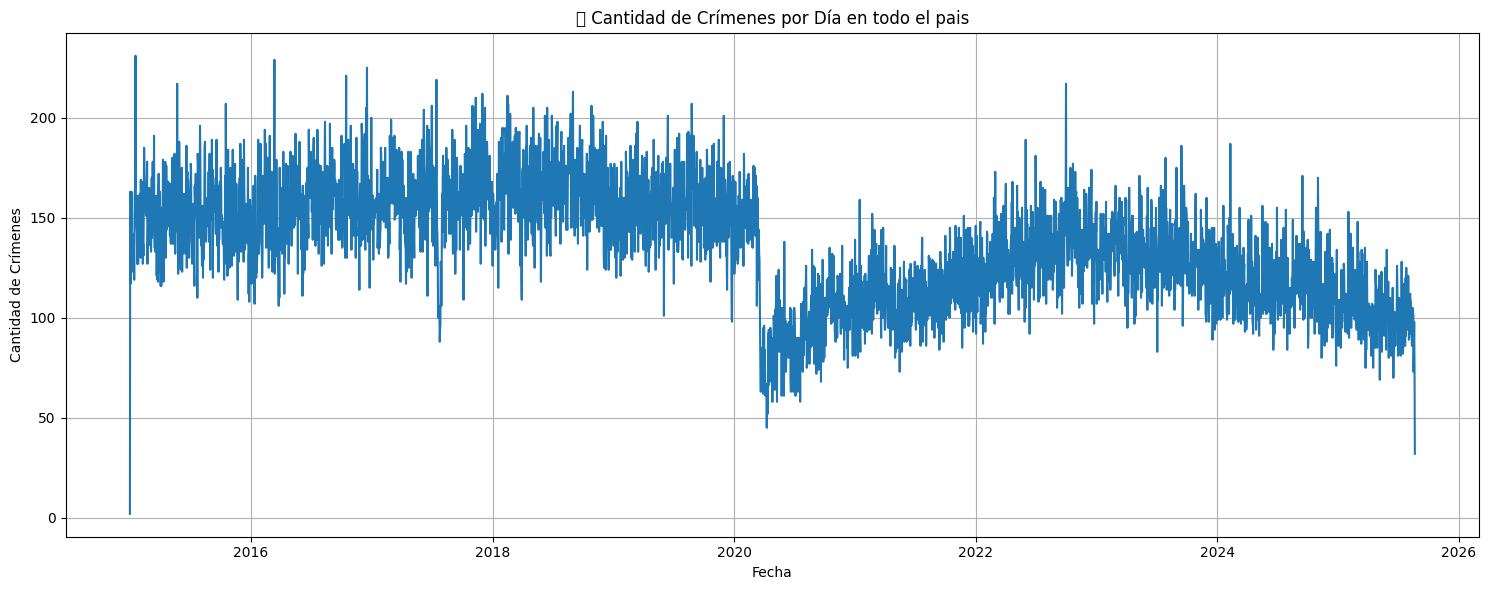

In [ ]:
# Asegúrate de que la columna 'date' esté en formato datetime
df_crime_all_2015_2025_clean['date'] = pd.to_datetime(df_crime_all_2015_2025_clean['date'])

# Agrupa por fecha para contar la cantidad de crímenes por día
crimes_por_dia = df_crime_all_2015_2025_clean.groupby('date').size().reset_index(name='cantidad_crimenes')

# Visualización de la serie de tiempo
plt.figure(figsize=(15, 6))
sns.lineplot(data=crimes_por_dia, x='date', y='cantidad_crimenes')
plt.title('📈 Cantidad de Crímenes por Día en todo el pais')
plt.xlabel('Fecha')
plt.ylabel('Cantidad de Crímenes')
plt.grid(True)
plt.tight_layout()
plt.show()

# data analysis
Frecuencia de Tipos de Crímenes en San José

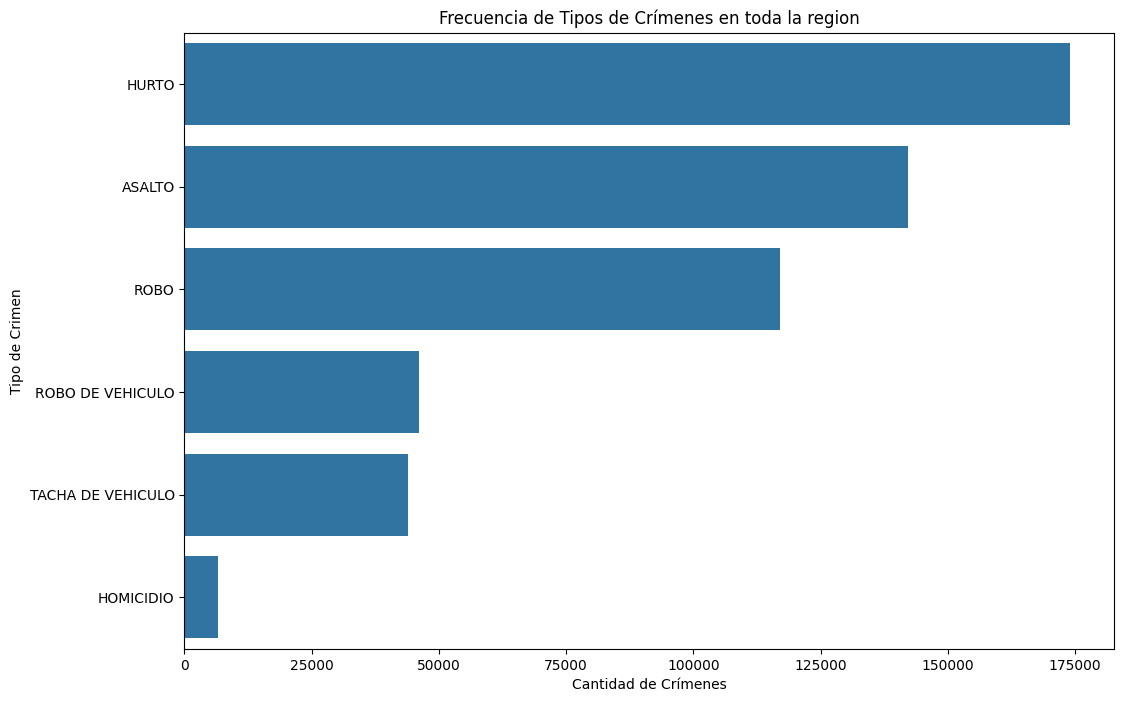

In [ ]:
# Suponiendo que la columna se llama 'tipo_crimen'
plt.figure(figsize=(12, 8))
sns.countplot(data=df_crime_all_2015_2025_clean, y='Delito', order=df_crime_all_2015_2025_clean['Delito'].value_counts().index)
plt.title('Frecuencia de Tipos de Crímenes en toda la region')
plt.xlabel('Cantidad de Crímenes')
plt.ylabel('Tipo de Crimen')
plt.show()

# data analysis
Frecuencia de Tipos de Crímenes en San José

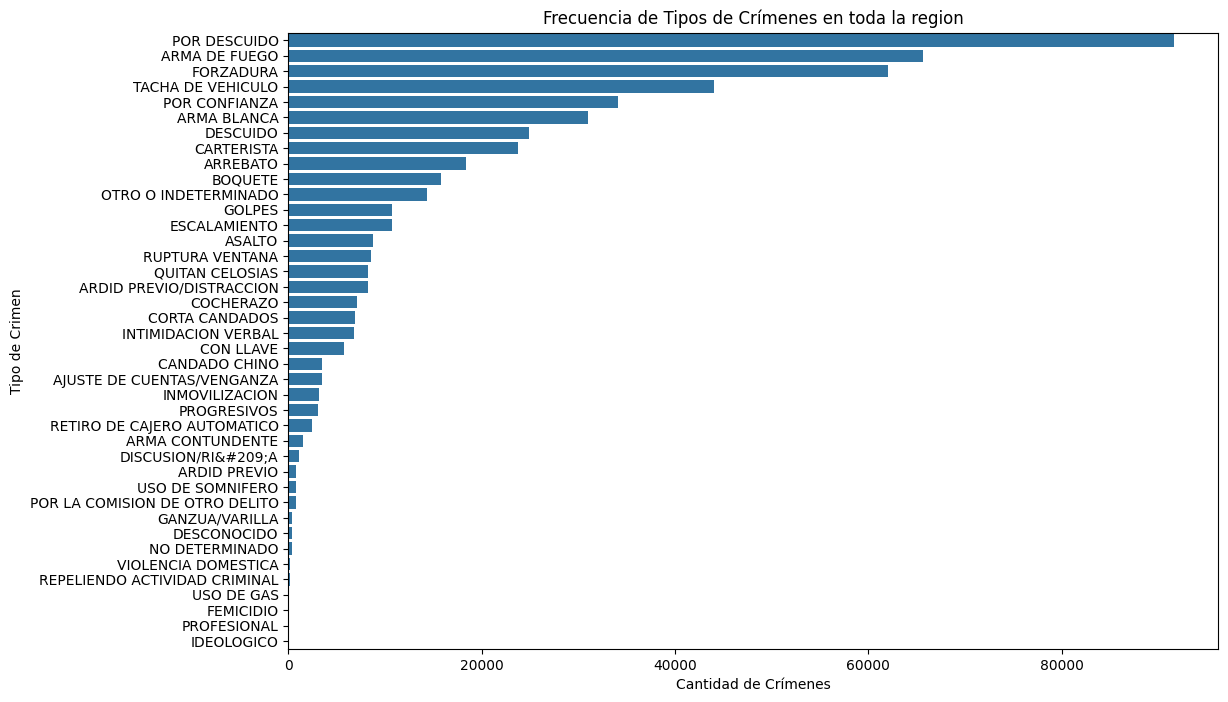

In [ ]:
# Suponiendo que la columna se llama 'tipo_crimen'
plt.figure(figsize=(12, 8))
sns.countplot(data=df_crime_all_2015_2025_clean, y='SubDelito', order=df_crime_all_2015_2025_clean['SubDelito'].value_counts().index)
plt.title('Frecuencia de Tipos de Crímenes en toda la region')
plt.xlabel('Cantidad de Crímenes')
plt.ylabel('Tipo de Crimen')
plt.show()

# data analysis
Distribución de Crímenes por Género de la Víctima

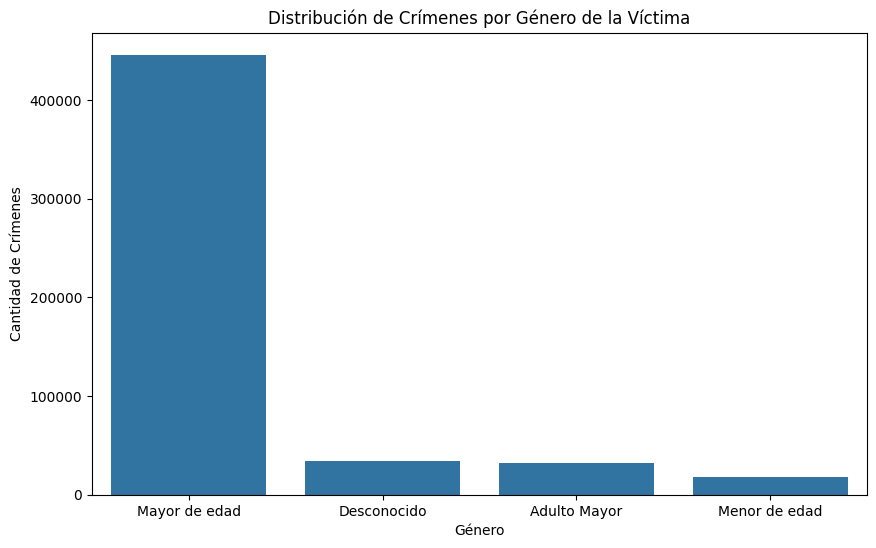

In [ ]:
# Gráfico de barras por Sexo
plt.figure(figsize=(10, 6))
sns.countplot(data=df_crime_all_2015_2025_clean, x='Sexo', order=df_crime_all_2015_2025_clean['Sexo'].value_counts().index)
plt.title('Distribución de Crímenes por Género de la Víctima')
plt.xlabel('Género')
plt.ylabel('Cantidad de Crímenes')
plt.show()

# data analysis
Crímenes por Género y Tipo de Víctima

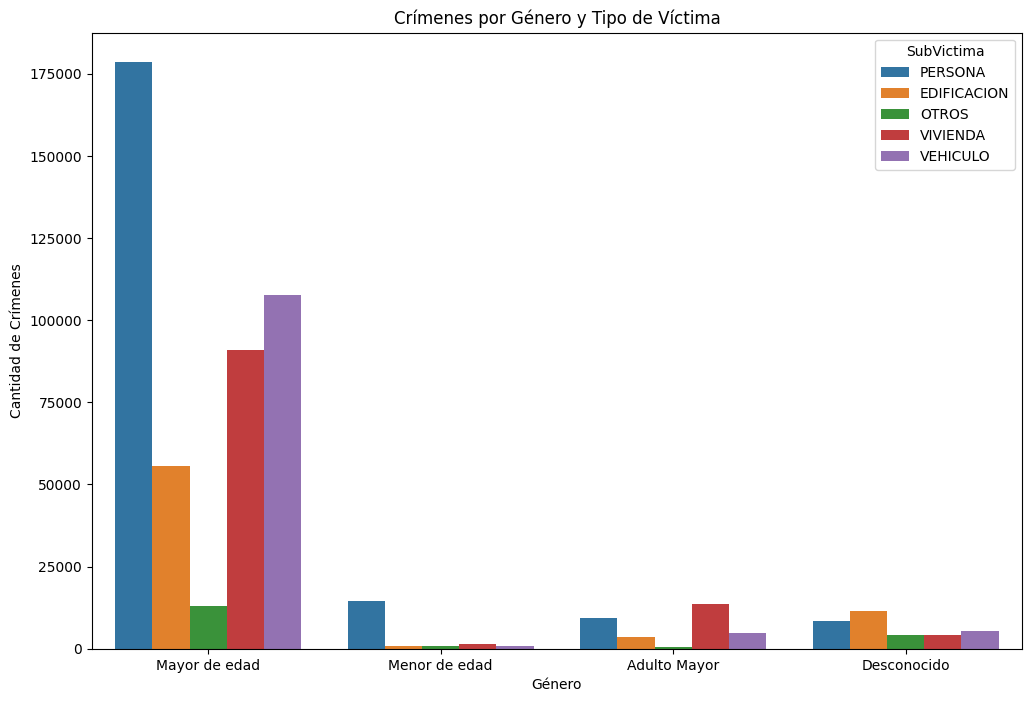

In [ ]:
# También puedes combinar ambos para un análisis más profundo
plt.figure(figsize=(12, 8))
sns.countplot(data=df_crime_all_2015_2025_clean, x='Sexo', hue='SubVictima')
plt.title('Crímenes por Género y Tipo de Víctima')
plt.xlabel('Género')
plt.ylabel('Cantidad de Crímenes')
plt.show()

# data analysis
Frecuencia de Tipos de Crímenes en San José por edad

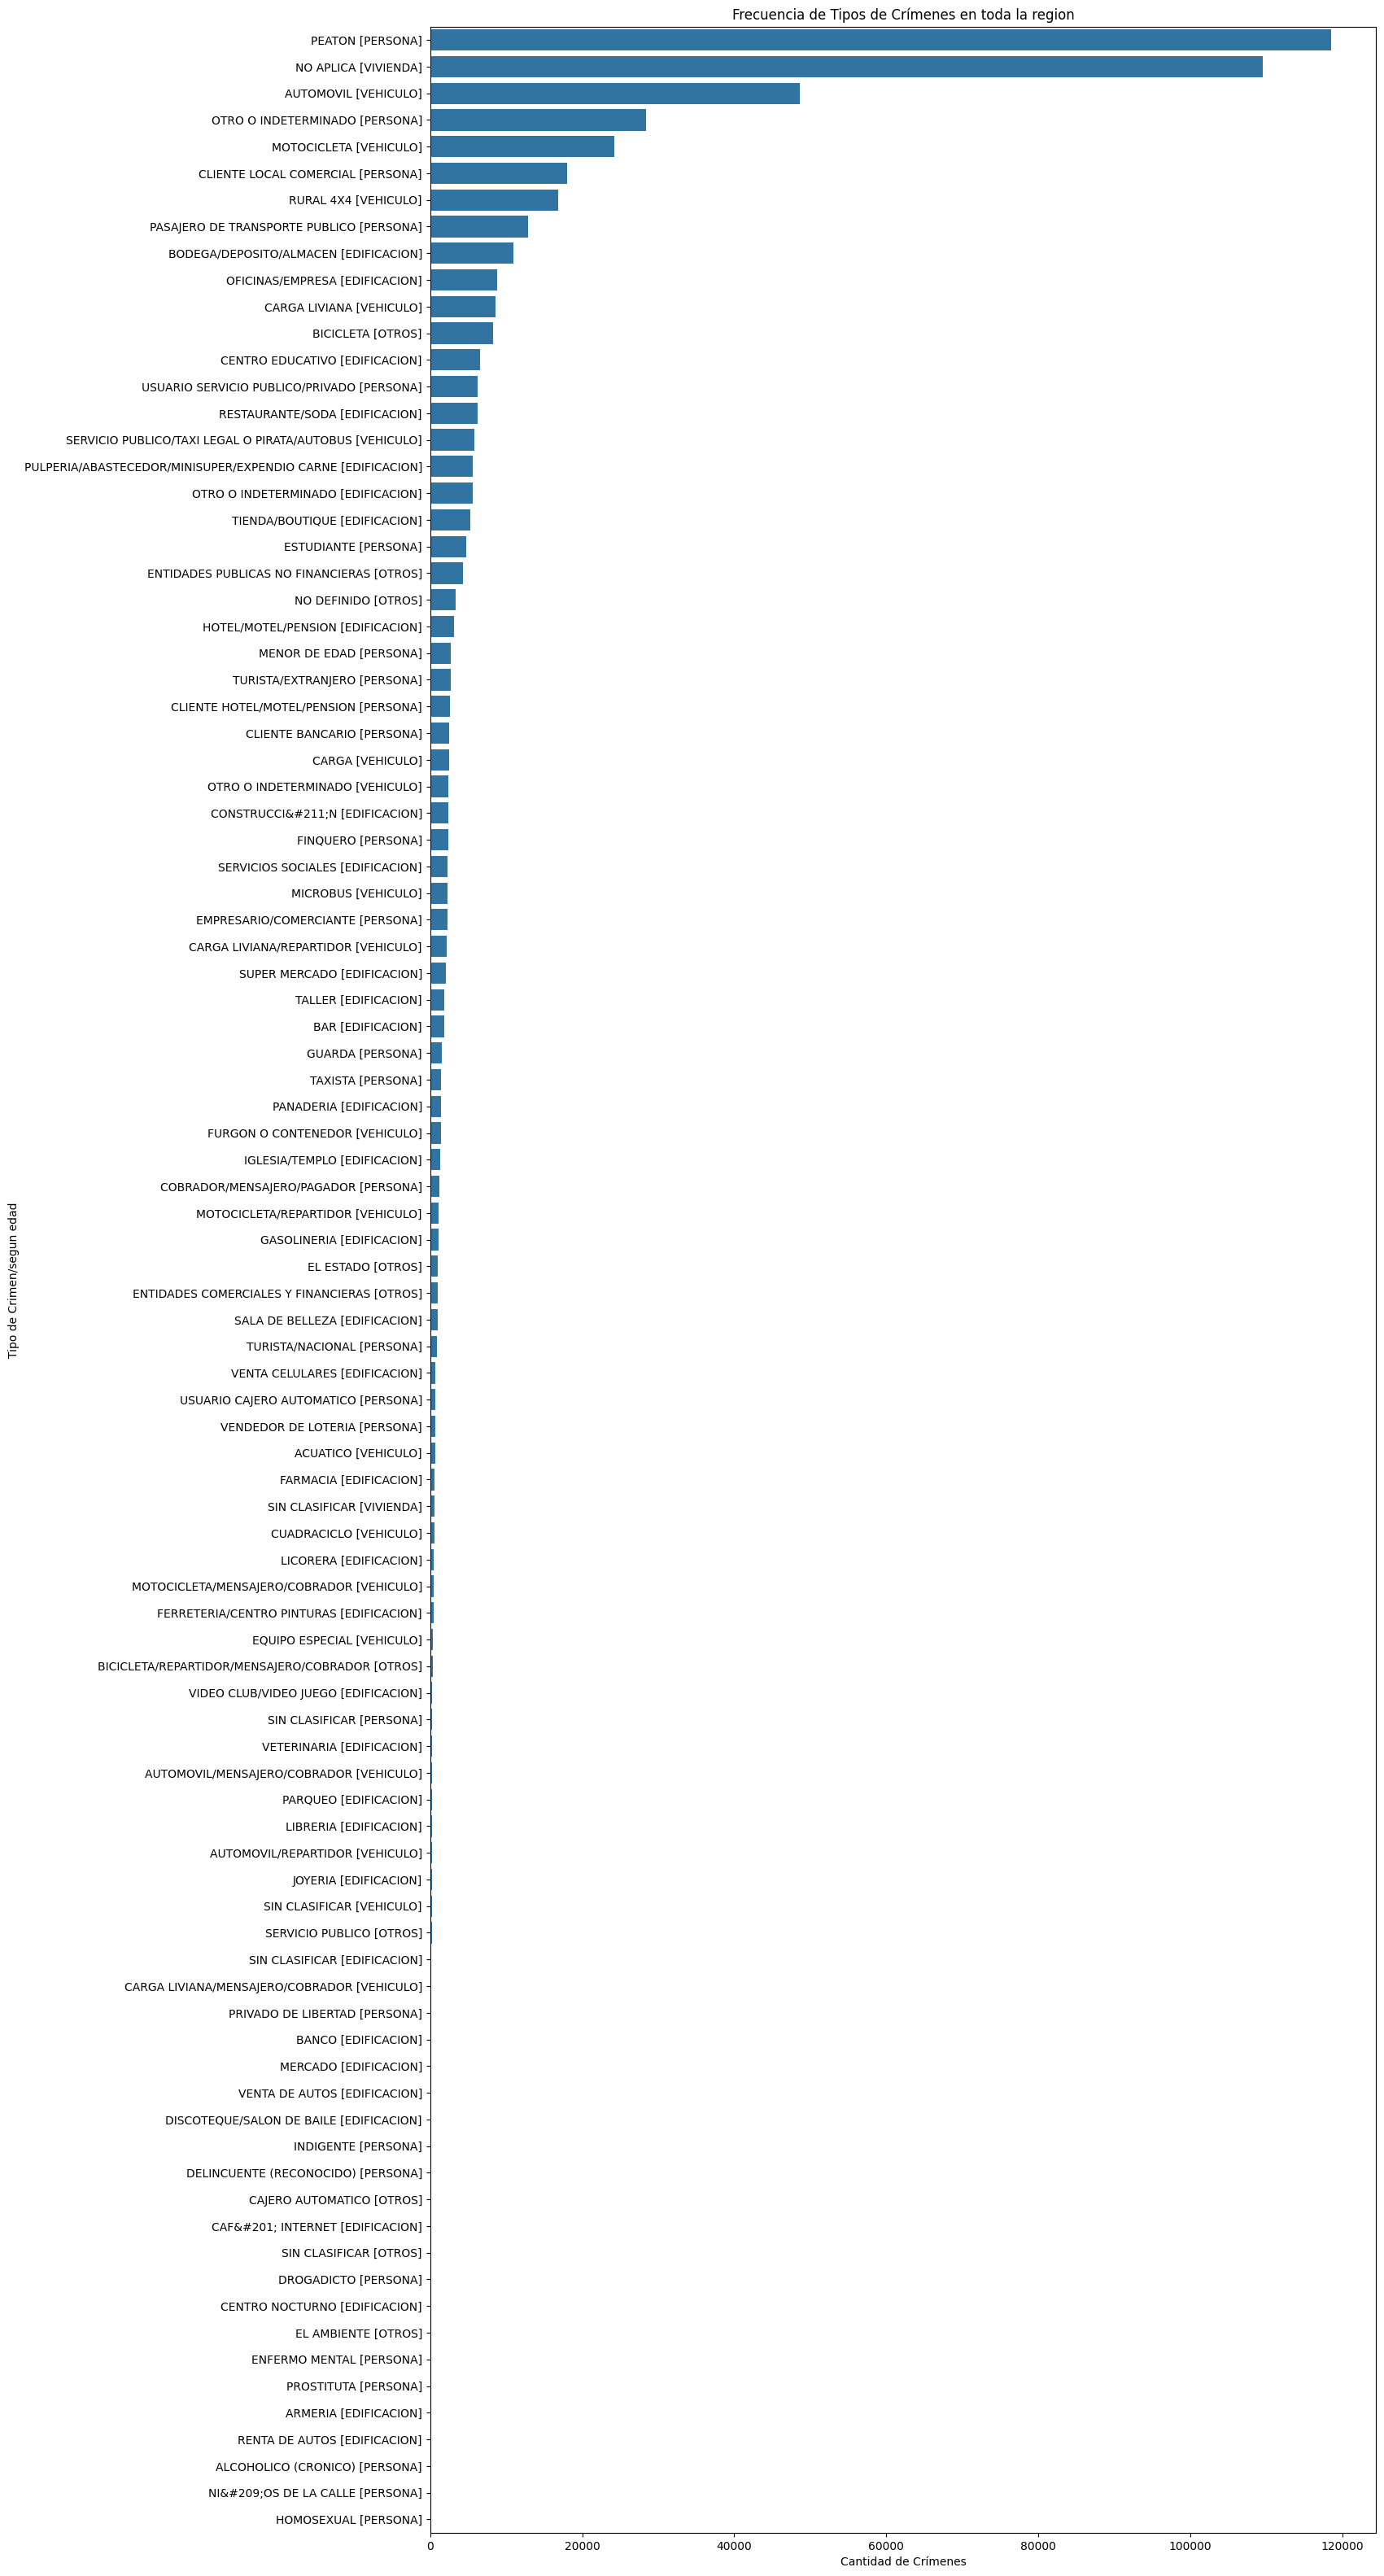

In [ ]:
# Suponiendo que la columna se llama 'tipo_crimen'
plt.figure(figsize=(15, 40))
sns.countplot(data=df_crime_all_2015_2025_clean, y='Edad', order=df_crime_all_2015_2025_clean['Edad'].value_counts().index)
plt.title('Frecuencia de Tipos de Crímenes en toda la region')
plt.xlabel('Cantidad de Crímenes')
plt.ylabel('Tipo de Crimen/segun edad')
plt.show()

# data analysis
Relación entre Temperatura EVENING y Cantidad de Crímenes en San José

In [ ]:
print(df_crime_all_2015_2025_clean.columns.tolist())

['Delito', 'SubDelito', 'date', 'Victima', 'SubVictima', 'Edad', 'Sexo', 'Nacionalidad', 'Provincia', 'canton', 'Distrito', 'MAX_TEMPERATURE_C', 'MIN_TEMPERATURE_C', 'WINDSPEED_MAX_KMH', 'TEMPERATURE_MORNING_C_6H', 'TEMPERATURE_NOON_C_12H', 'TEMPERATURE_EVENING_C_18H', 'PRECIP_TOTAL_DAY_MM', 'HUMIDITY_MAX_PERCENT', 'VISIBILITY_AVG_KM', 'PRESSURE_MAX_MB', 'CLOUDCOVER_AVG_PERCENT', 'HEATINDEX_MAX_C', 'DEWPOINT_MAX_C', 'WINDTEMP_MAX_C', 'WEATHER_CODE_MORNING_6H', 'WEATHER_CODE_NOON_12H', 'WEATHER_CODE_EVENING_18H', 'TOTAL_SNOW_MM', 'UV_INDEX', 'SUNHOUR', 'OPINION', 'SUNSET', 'SUNRISE', 'TEMPERATURE_NIGHT_C_3H', 'WEATHER_CODE_NIGHT_3H', 'TEMPERATURE_9H', 'WEATHER_CODE_9H', 'TEMPERATURE_15H', 'WEATHER_CODE_15H', 'TEMPERATURE_21H', 'WEATHER_CODE_21H', 'TEMPERATURE_MIDNIGHT_0H', 'WEATHER_CODE_MIDNIGHT_0H']


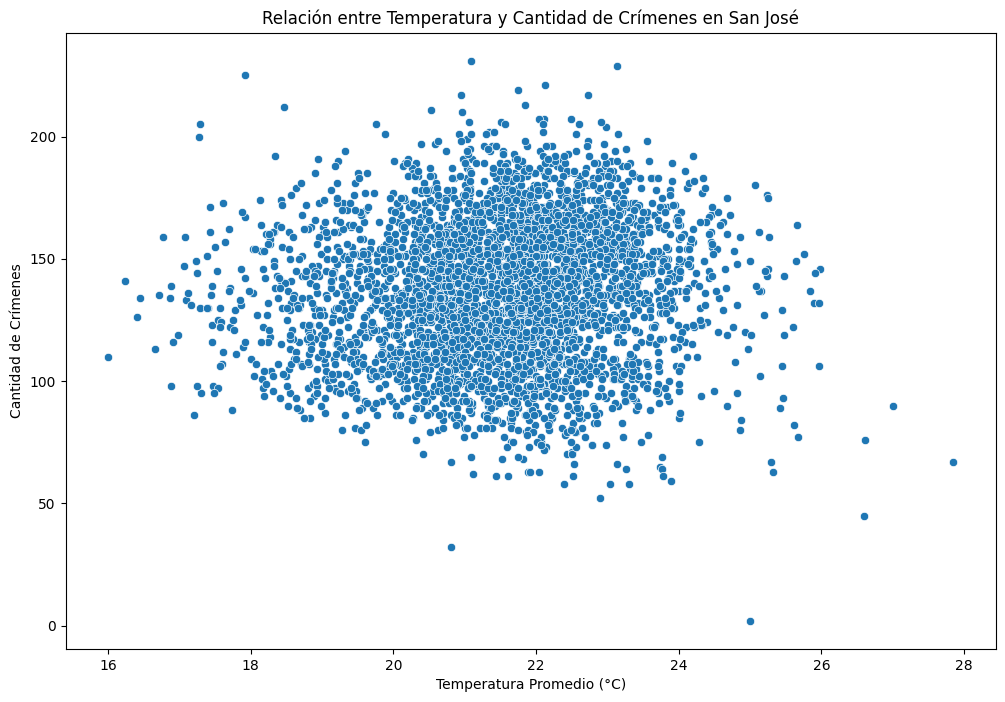

In [ ]:
# Paso 1: Asegúrate de que la columna de fecha sea de tipo datetime
df_crime_all_2015_2025_clean['date'] = pd.to_datetime(df_crime_all_2015_2025_clean['date'])

# Paso 2: Agrupa por fecha para contar los crímenes y obtener la temperatura promedio
# (Si tienes múltiples registros de temperatura por día, promedia la temperatura)
df_diario = df_crime_all_2015_2025_clean.groupby('date').agg(
    cantidad_crimenes=('Delito', 'count'),
    temperatura_promedio=('TEMPERATURE_EVENING_C_18H', 'mean')
).reset_index()

# Paso 3: Crea el gráfico de dispersión
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_diario, x='temperatura_promedio', y='cantidad_crimenes')
plt.title('Relación entre Temperatura y Cantidad de Crímenes en San José')
plt.xlabel('Temperatura Promedio (°C)')
plt.ylabel('Cantidad de Crímenes')
plt.show()

# data analysis
Relación entre Temperatura Máxima y Cantidad de Crímenes

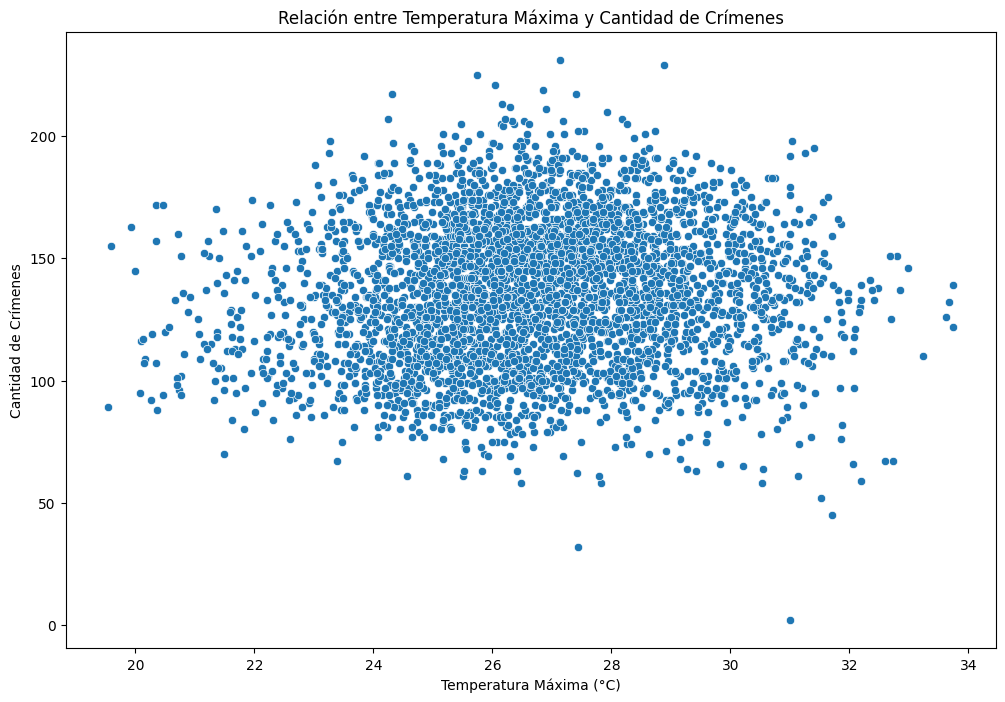

In [ ]:
# Asegúrate de que 'Date' sea de tipo datetime si no lo está
df_crime_all_2015_2025_clean['date'] = pd.to_datetime(df_crime_all_2015_2025_clean['date'])

# Agrupa por fecha para contar los crímenes y obtener la temperatura máxima
df_diario = df_crime_all_2015_2025_clean.groupby('date').agg(
    cantidad_crimenes=('Delito', 'count'),
    max_temp=('MAX_TEMPERATURE_C', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_diario, x='max_temp', y='cantidad_crimenes')
plt.title('Relación entre Temperatura Máxima y Cantidad de Crímenes')
plt.xlabel('Temperatura Máxima (°C)')
plt.ylabel('Cantidad de Crímenes')
plt.show()

# data analysis
Cantidad de Crímenes por Rango de Humedad Máxima

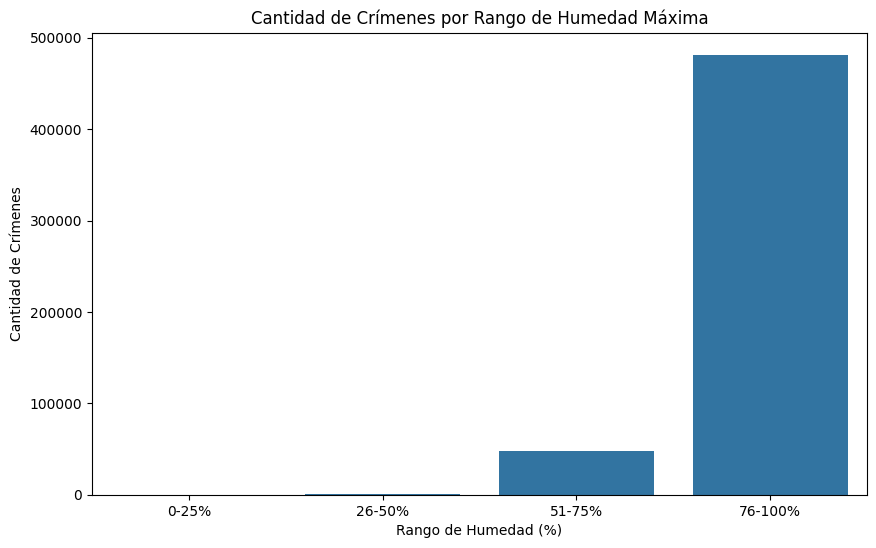

In [ ]:
# Puedes agrupar la humedad en rangos
bins = [0, 25, 50, 75, 100]
labels = ['0-25%', '26-50%', '51-75%', '76-100%']
df_crime_all_2015_2025_clean['rango_humedad'] = pd.cut(df_crime_all_2015_2025_clean['HUMIDITY_MAX_PERCENT'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10, 6))
sns.countplot(data=df_crime_all_2015_2025_clean, x='rango_humedad')
plt.title('Cantidad de Crímenes por Rango de Humedad Máxima')
plt.xlabel('Rango de Humedad (%)')
plt.ylabel('Cantidad de Crímenes')
plt.show()

# data analysis
Distribución de Delitos por Rango de Humedad y Tipo de Delito

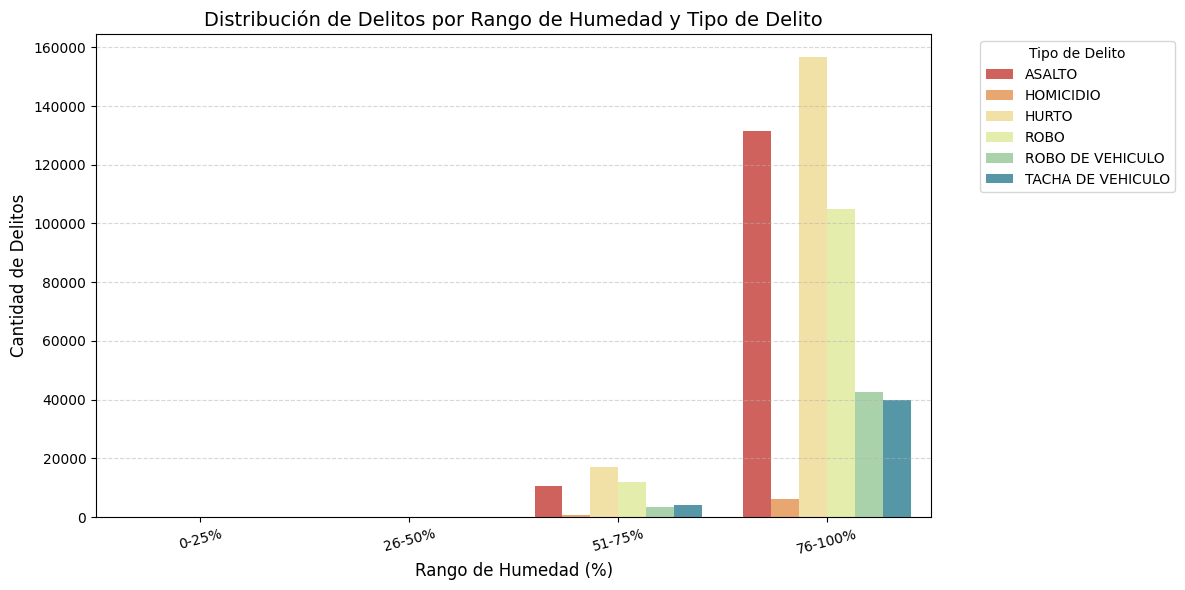

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_crime_all_2015_2025_clean, x='rango_humedad', hue='Delito', palette='Spectral')
plt.title('Distribución de Delitos por Rango de Humedad y Tipo de Delito', fontsize=14)
plt.xlabel('Rango de Humedad (%)', fontsize=12)
plt.ylabel('Cantidad de Delitos', fontsize=12)
plt.legend(title='Tipo de Delito', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# data analysis
Mapa de Calor: Delitos por Tipo y Humedad

/tmp/ipython-input-4193972810.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_crime_all_2015_2025_clean.pivot_table(index='Delito', columns='rango_humedad', aggfunc='size', fill_value=0)


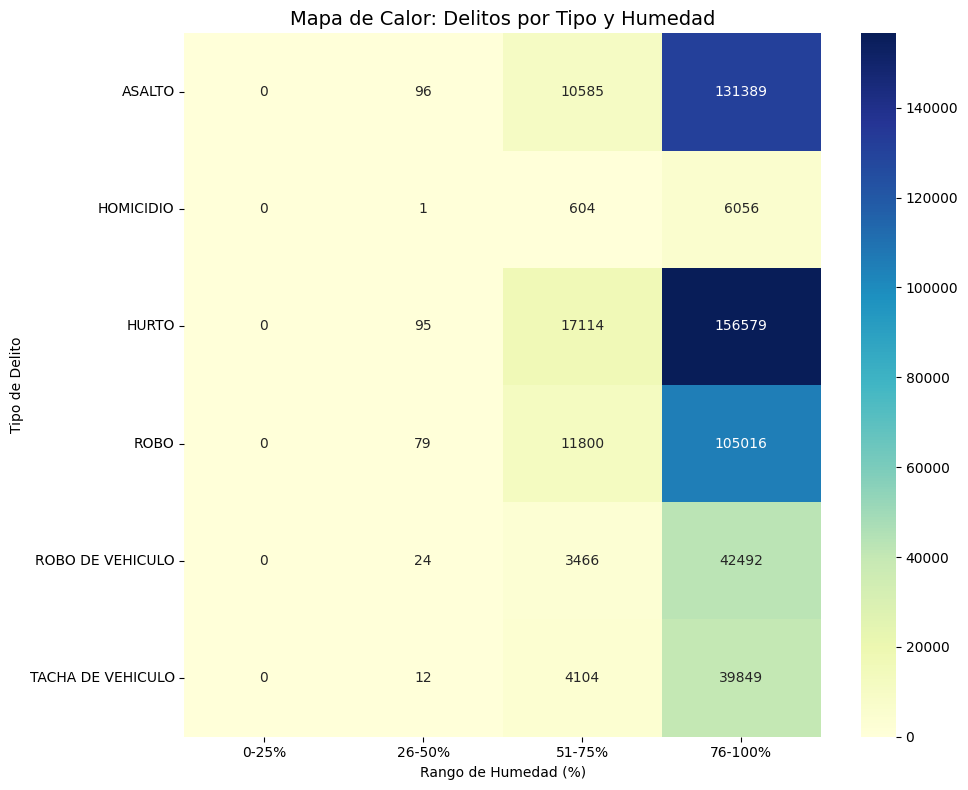

In [ ]:
pivot = df_crime_all_2015_2025_clean.pivot_table(index='Delito', columns='rango_humedad', aggfunc='size', fill_value=0)

plt.figure(figsize=(10, 8))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Mapa de Calor: Delitos por Tipo y Humedad', fontsize=14)
plt.xlabel('Rango de Humedad (%)')
plt.ylabel('Tipo de Delito')
plt.tight_layout()
plt.show()

# data analysis
Distribución de Delitos por Rango de Nubosidad y Tipo de Delito

In [ ]:
# Define los límites de los rangos y las etiquetas
bins = [0, 25, 50, 75, 100]
labels = ['Despejado a poco nuboso', 'Parcialmente nuboso', 'Mayormente nuboso', 'Cubierto']

# Crea la nueva columna 'RANGO_NUBOSIDAD'
df_crime_all_2015_2025_clean['RANGO_NUBOSIDAD'] = pd.cut(df_crime_all_2015_2025_clean['CLOUDCOVER_AVG_PERCENT'],
                                         bins=bins,
                                         labels=labels,
                                         right=False)

/tmp/ipython-input-2422400649.py:15: UserWarning: Glyph 127781 (\N{WHITE SUN BEHIND CLOUD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127781 (\N{WHITE SUN BEHIND CLOUD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


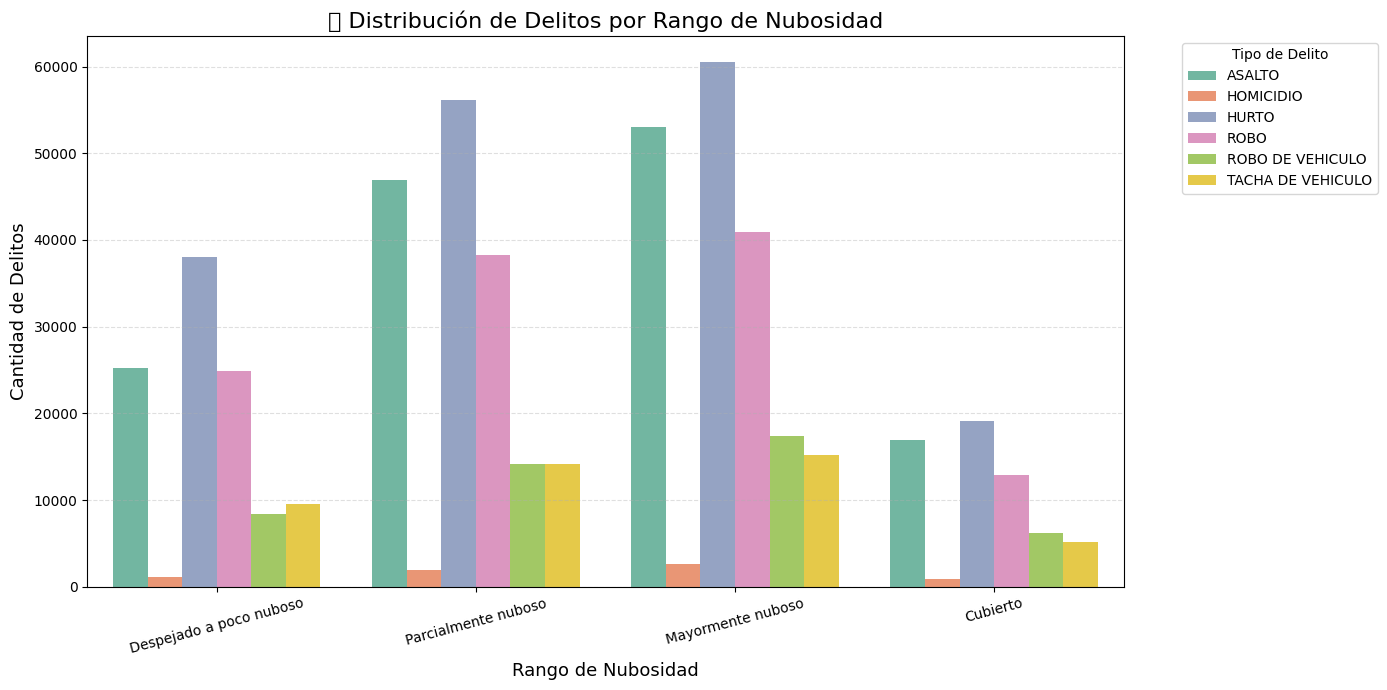

In [ ]:
plt.figure(figsize=(14, 7))
sns.countplot(
    data=df_crime_all_2015_2025_clean,
    x='RANGO_NUBOSIDAD',
    hue='Delito',  # O 'DELITO_SIMBOLICO' si agrupaste
    palette='Set2',
    order=labels + ['Sin dato'] if 'Sin dato' in df_crime_all_2015_2025_clean['RANGO_NUBOSIDAD'].unique() else labels
)
plt.title('🌥️ Distribución de Delitos por Rango de Nubosidad', fontsize=16)
plt.xlabel('Rango de Nubosidad', fontsize=13)
plt.ylabel('Cantidad de Delitos', fontsize=13)
plt.legend(title='Tipo de Delito', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# data analisys
Mapa de Calor: Delitos por Tipo y Rango de Precipitación

In [ ]:
# Definir los rangos y las etiquetas para la precipitación
bins = [0, 0.1, 5, 20, np.inf]
labels = ['Sin lluvia', 'Lluvia leve', 'Lluvia moderada', 'Lluvia fuerte']

# Crear la nueva columna 'RANGO_PRECIPITACION' en el DataFrame correcto
df_crime_all_2015_2025_clean['RANGO_PRECIPITACION'] = pd.cut(df_crime_all_2015_2025_clean['PRECIP_TOTAL_DAY_MM'], bins=bins, labels=labels, right=False)

# Si tienes valores nulos o quieres tratar los ceros de forma especial, puedes ajustar los rangos.
# Por ejemplo, el 0 está incluido en 'Sin lluvia' gracias al 'right=False'.

/tmp/ipython-input-468117229.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_crime_all_2015_2025_clean.pivot_table(index='Delito', columns='RANGO_PRECIPITACION', aggfunc='size', fill_value=0)


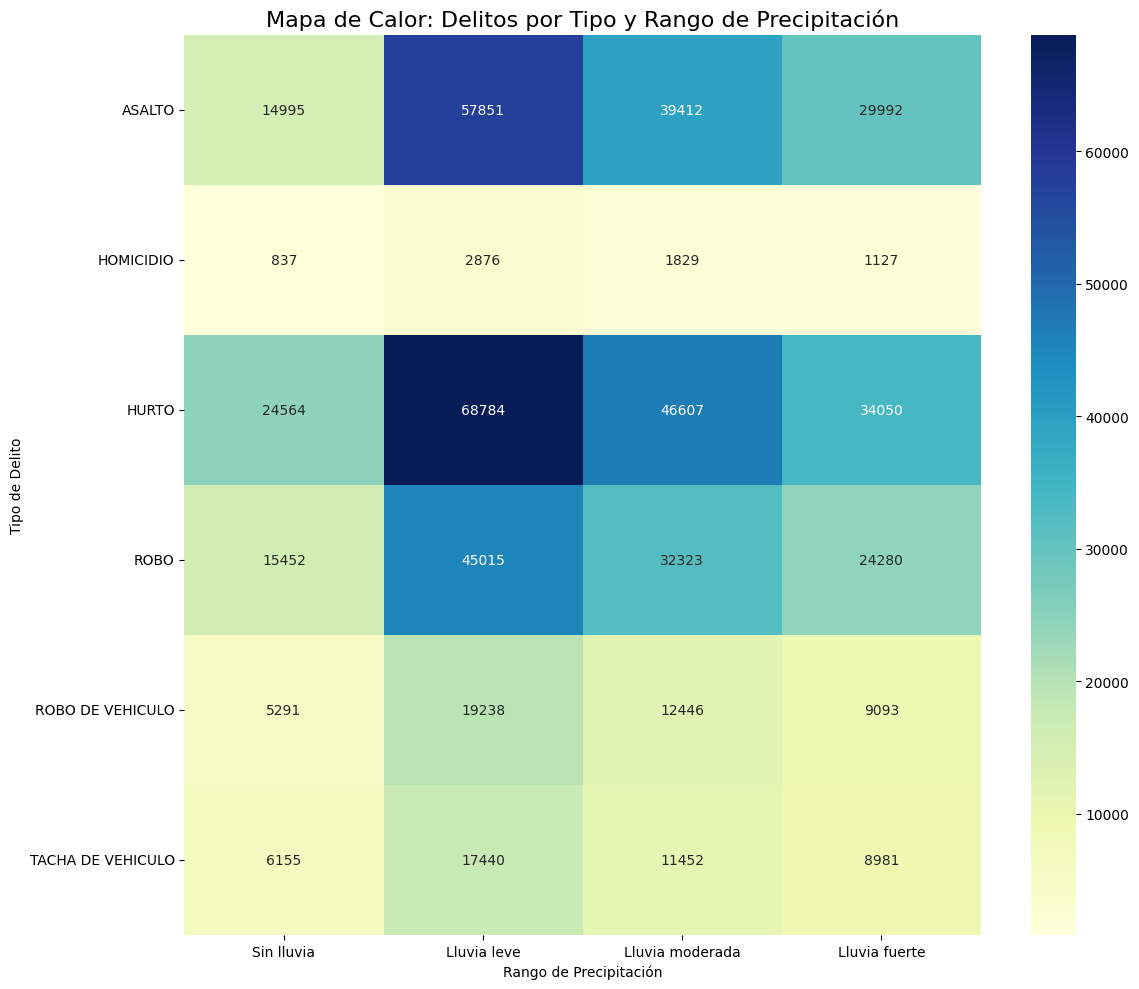

In [ ]:
# Crear la tabla dinámica
# El índice 'DELITO' y la columna 'RANGO_PRECIPITACION' ya existen ahora
pivot = df_crime_all_2015_2025_clean.pivot_table(index='Delito', columns='RANGO_PRECIPITACION', aggfunc='size', fill_value=0)

# Crear el mapa de calor
plt.figure(figsize=(12, 10))
sns.heatmap(pivot, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Mapa de Calor: Delitos por Tipo y Rango de Precipitación', fontsize=16)
plt.xlabel('Rango de Precipitación')
plt.ylabel('Tipo de Delito')
plt.tight_layout()
plt.show()

# data analysis
Distribución de Delitos por Rango de precipitacion y Tipo de Delito

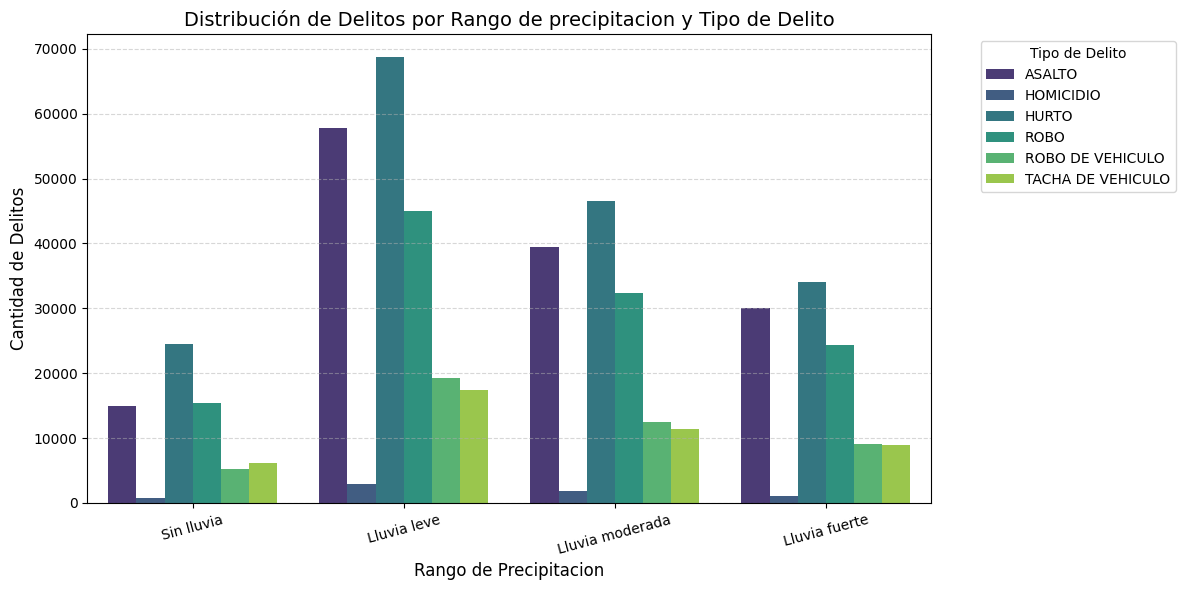

In [ ]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_crime_all_2015_2025_clean, x='RANGO_PRECIPITACION', hue='Delito', palette='viridis')
plt.title('Distribución de Delitos por Rango de precipitacion y Tipo de Delito', fontsize=14)
plt.xlabel('Rango de Precipitacion', fontsize=12)
plt.ylabel('Cantidad de Delitos', fontsize=12)
plt.legend(title='Tipo de Delito', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# data analysis
Mapa de Calor: Delitos por Tipo y Rango de Nubosidad

In [ ]:
# Definir los límites de los rangos de nubosidad
bins_nubosidad = [0, 25, 50, 75, 100]
# Definir las etiquetas para los rangos
labels_nubosidad = ['Despejado (0-25%)', 'Parcialmente Nublado (26-50%)', 'Nublado (51-75%)', 'Muy Nublado (76-100%)']

# Crear la nueva columna 'RANGO_NUBOSIDAD' en el DataFrame
df_crime_all_2015_2025_clean['RANGO_NUBOSIDAD'] = pd.cut(df_crime_all_2015_2025_clean['CLOUDCOVER_AVG_PERCENT'], bins=bins_nubosidad, labels=labels_nubosidad, include_lowest=True)

/tmp/ipython-input-4007297260.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_nubosidad = df_crime_all_2015_2025_clean.pivot_table(index='Delito', columns='RANGO_NUBOSIDAD', aggfunc='size', fill_value=0)


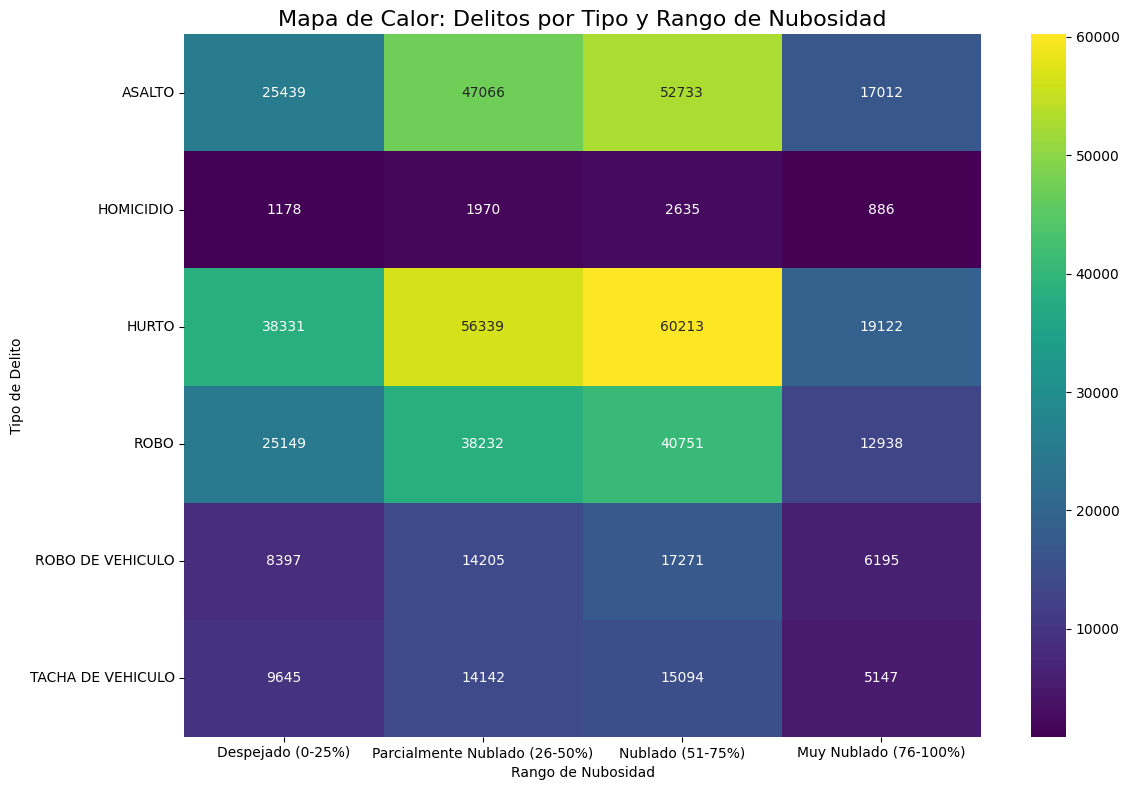

In [ ]:
# Crear la tabla pivote para el mapa de calor
pivot_nubosidad = df_crime_all_2015_2025_clean.pivot_table(index='Delito', columns='RANGO_NUBOSIDAD', aggfunc='size', fill_value=0)

# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 8))

# Crear el mapa de calor con los datos de la tabla pivote
sns.heatmap(pivot_nubosidad, annot=True, fmt='d', cmap='viridis')

# Añadir títulos y etiquetas
plt.title('Mapa de Calor: Delitos por Tipo y Rango de Nubosidad', fontsize=16)
plt.xlabel('Rango de Nubosidad')
plt.ylabel('Tipo de Delito')

# Ajustar el diseño y mostrar el gráfico
plt.tight_layout()
plt.show()

# data visualization
Relación entre Precipitación y Cantidad de Crímenes

In [ ]:
# Asumiendo que 'df_weather_sanjose_2009_2025' es tu dataset original
df_original_crimen_weather = df_crime_all_2015_2025_clean

# 🚀 1. Crear una copia profunda e independiente
df_copia_para_trabajar_crimen_weather = df_original_crimen_weather.copy()

display(df_copia_para_trabajar_crimen_weather.head())

,Delito,SubDelito,date,Victima,SubVictima,Edad,Sexo,Nacionalidad,Provincia,canton,...,WEATHER_CODE_9H,TEMPERATURE_15H,WEATHER_CODE_15H,TEMPERATURE_21H,WEATHER_CODE_21H,TEMPERATURE_MIDNIGHT_0H,WEATHER_CODE_MIDNIGHT_0H,rango_humedad,RANGO_NUBOSIDAD,RANGO_PRECIPITACION
0,ASALTO,ARMA BLANCA,2015-01-01,00:00:00 - 02:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,NICARAGUA,alajuela,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76-100%,Despejado (0-25%),Sin lluvia
1,ASALTO,ARMA BLANCA,2015-01-11,06:00:00 - 08:59:59,EDIFICACION,PULPERIA/ABASTECEDOR/MINISUPER/EXPENDIO CARNE ...,Mayor de edad,HOMBRE,COSTA RICA,puntarenas,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76-100%,Despejado (0-25%),Sin lluvia
2,ASALTO,ARMA BLANCA,2015-01-07,15:00:00 - 17:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,HOMBRE,COSTA RICA,san jose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76-100%,Despejado (0-25%),Lluvia leve
3,ASALTO,ARMA BLANCA,2015-01-04,18:00:00 - 20:59:59,OTROS,NO DEFINIDO [OTROS],Mayor de edad,MUJER,NICARAGUA,san jose,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76-100%,Parcialmente Nublado (26-50%),Lluvia leve
4,ASALTO,ARMA BLANCA,2015-01-14,06:00:00 - 08:59:59,PERSONA,PEATON [PERSONA],Mayor de edad,MUJER,COSTA RICA,cartago,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76-100%,Despejado (0-25%),Lluvia leve


In [ ]:
df_copia_para_trabajar_crimen_weather['Delito'] = df_copia_para_trabajar_crimen_weather['Delito'].astype('category').cat.codes
df_copia_para_trabajar_crimen_weather['SubDelito'] = df_copia_para_trabajar_crimen_weather['SubDelito'].astype('category').cat.codes
df_copia_para_trabajar_crimen_weather['Distrito'] = df_copia_para_trabajar_crimen_weather['Distrito'].astype('category').cat.codes
df_copia_para_trabajar_crimen_weather['Sexo'] = df_copia_para_trabajar_crimen_weather['Sexo'].astype('category').cat.codes
df_copia_para_trabajar_crimen_weather['Victima'] = df_copia_para_trabajar_crimen_weather['Victima'].astype('category').cat.codes
df_copia_para_trabajar_crimen_weather['Edad'] = df_copia_para_trabajar_crimen_weather['Edad'].astype('category').cat.codes
df_copia_para_trabajar_crimen_weather['date'] = df_copia_para_trabajar_crimen_weather['date'].astype('category').cat.codes
df_copia_para_trabajar_crimen_weather['SubVictima'] = df_copia_para_trabajar_crimen_weather['SubVictima'].astype('category').cat.codes

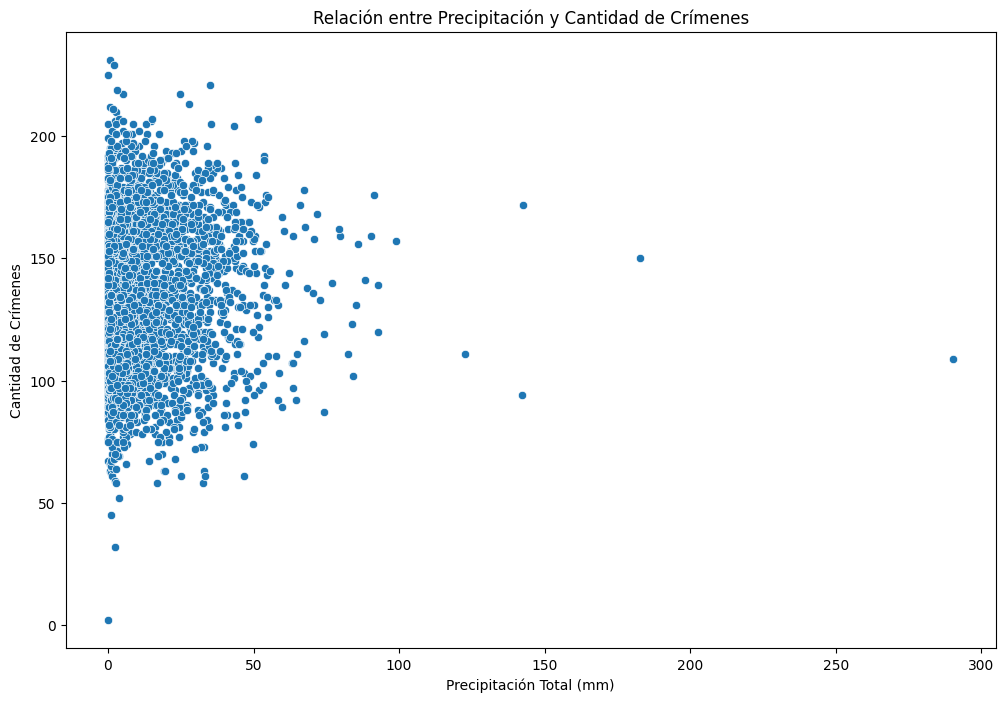

In [ ]:
df_diario = df_copia_para_trabajar_crimen_weather.groupby('date').agg(
    cantidad_crimenes=('Delito', 'count'),
    precipitacion_total=('PRECIP_TOTAL_DAY_MM', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_diario, x='precipitacion_total', y='cantidad_crimenes')
plt.title('Relación entre Precipitación y Cantidad de Crímenes')
plt.xlabel('Precipitación Total (mm)')
plt.ylabel('Cantidad de Crímenes')
plt.show()

# data visualization
Distribución de Tipos de Delito por Cantón




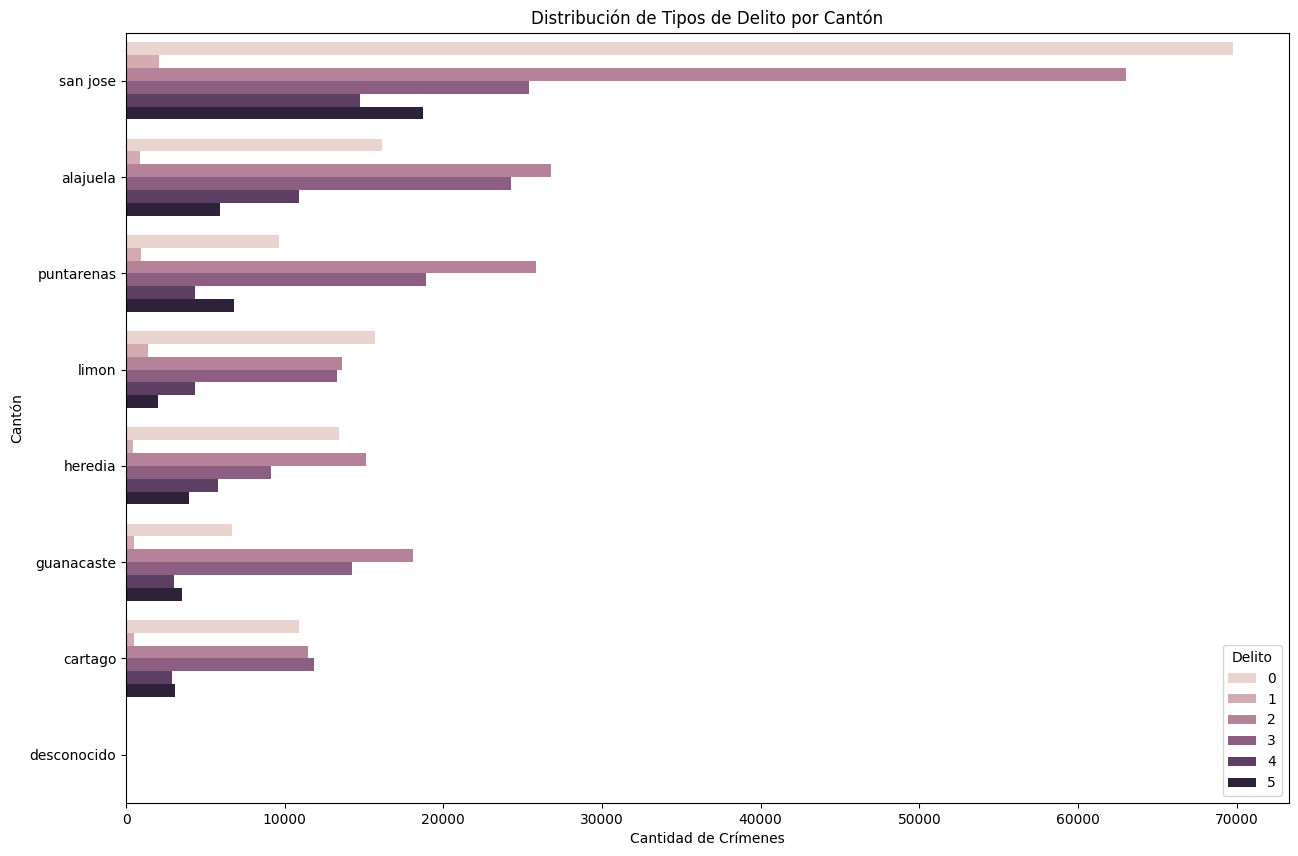

In [ ]:
plt.figure(figsize=(15, 10))
sns.countplot(data=df_copia_para_trabajar_crimen_weather , y='canton', hue='Delito', order=df_copia_para_trabajar_crimen_weather ['canton'].value_counts().index)
plt.title('Distribución de Tipos de Delito por Cantón')
plt.xlabel('Cantidad de Crímenes')
plt.ylabel('Cantón')
plt.legend(title='Delito')
plt.show()

# data visualization
Crímenes por Tipo de Víctima y Género

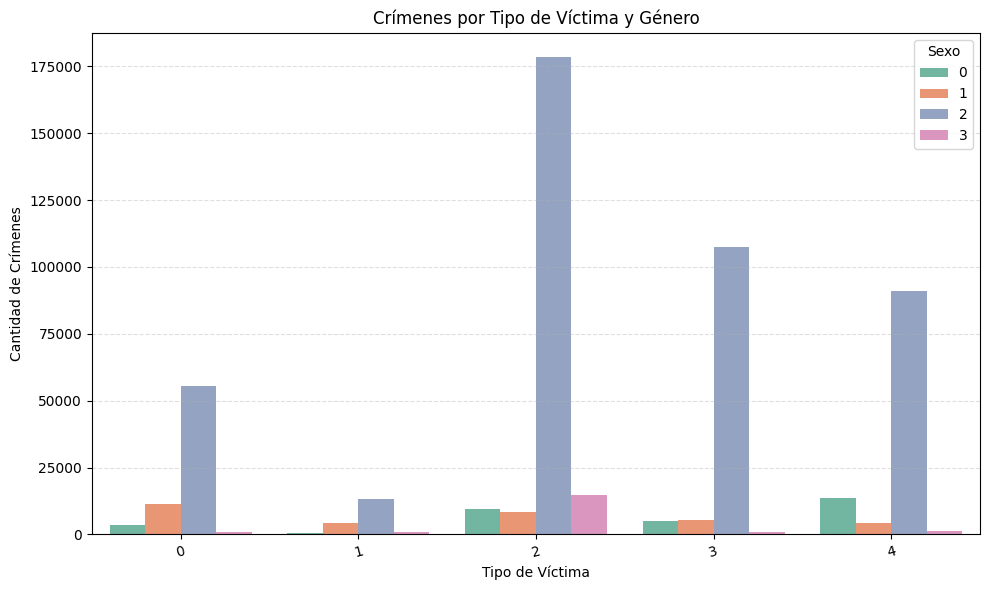

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_copia_para_trabajar_crimen_weather, x='SubVictima', hue='Sexo', palette='Set2')
plt.title('Crímenes por Tipo de Víctima y Género')
plt.xlabel('Tipo de Víctima')
plt.ylabel('Cantidad de Crímenes')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# data visualization
Distribución de la Temperatura Máxima por Tipo de Delito

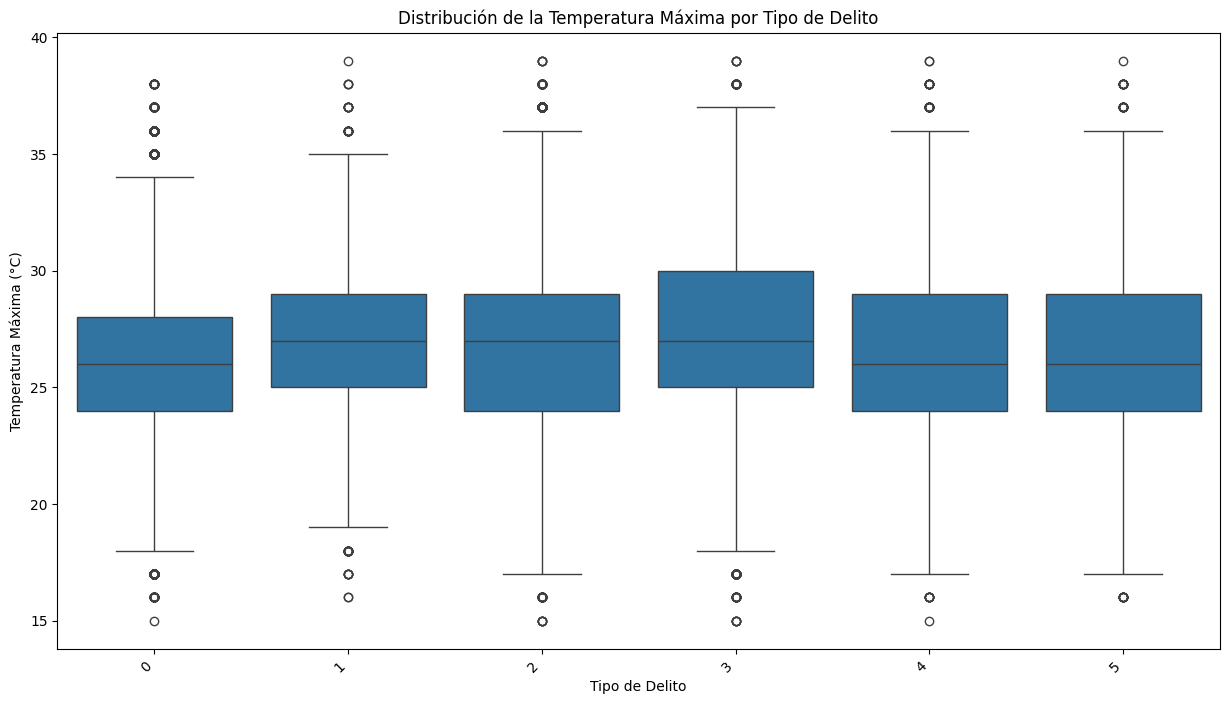

In [ ]:
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_copia_para_trabajar_crimen_weather, x='Delito', y='MAX_TEMPERATURE_C')
plt.title('Distribución de la Temperatura Máxima por Tipo de Delito')
plt.xlabel('Tipo de Delito')
plt.ylabel('Temperatura Máxima (°C)')
plt.xticks(rotation=45, ha='right')
plt.show()

# data visualization
Crímenes y Temperatura Máxima a lo Largo del Tiempo

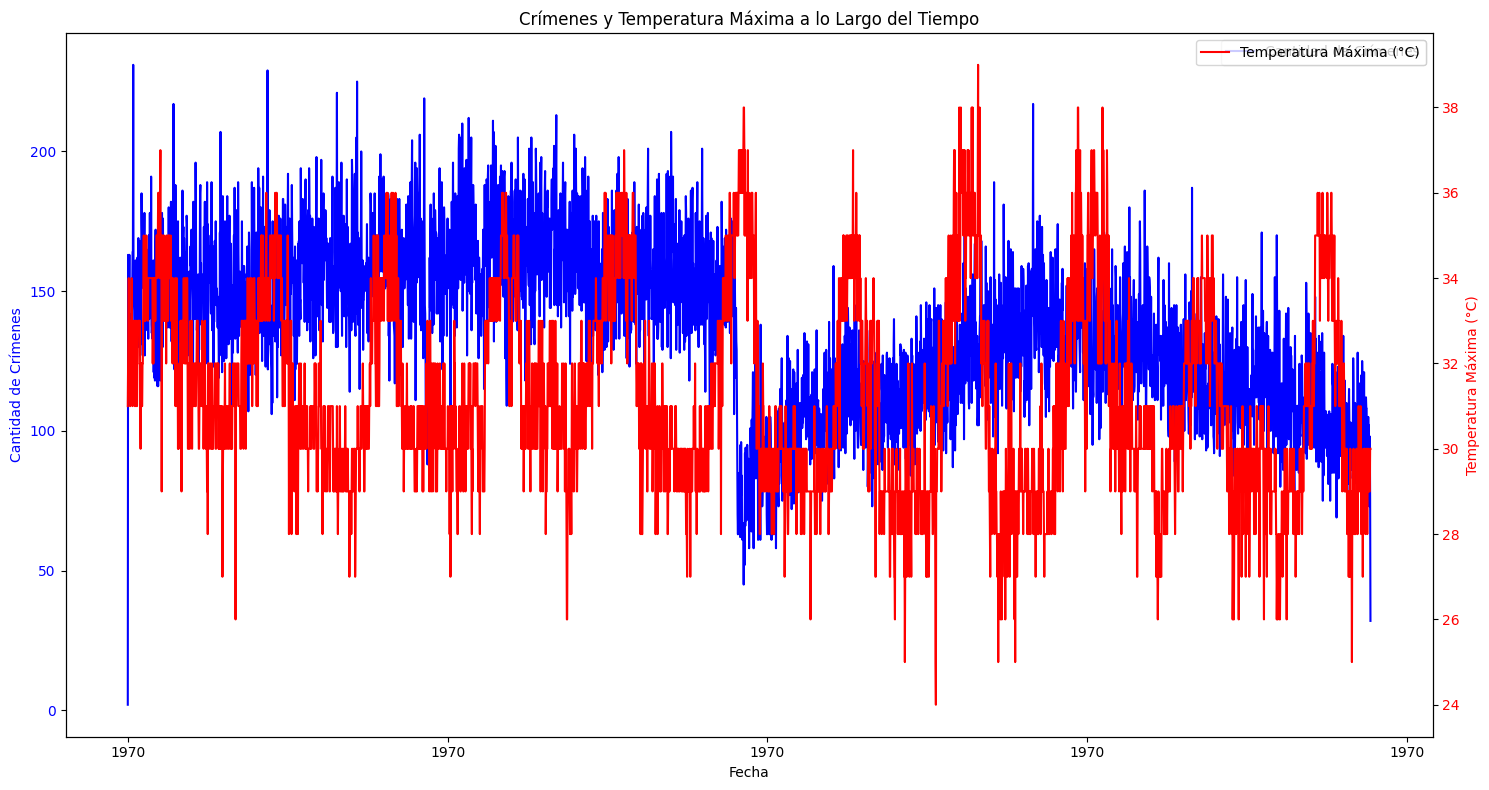

In [ ]:
# Convertir la columna 'Date' a formato de fecha
df_copia_para_trabajar_crimen_weather['date'] = pd.to_datetime(df_copia_para_trabajar_crimen_weather['date'])

# Agrupar por fecha para contar crímenes y obtener la temperatura promedio diaria
df_diario = df_copia_para_trabajar_crimen_weather.groupby('date').agg(
    cantidad_crimenes=('Delito', 'count'),
    temperatura_max_diaria=('MAX_TEMPERATURE_C', 'max')
).reset_index()

# Crear el gráfico
fig, ax1 = plt.subplots(figsize=(15, 8))

# Usa 'DATE' en lugar de 'Date'
sns.lineplot(data=df_diario, x='date', y='cantidad_crimenes', ax=ax1, color='blue', label='Cantidad de Crímenes')
ax1.set_xlabel('Fecha')
ax1.set_ylabel('Cantidad de Crímenes', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Crear un segundo eje para la temperatura
ax2 = ax1.twinx()
# Usa 'DATE' en lugar de 'Date'
sns.lineplot(data=df_diario, x='date', y='temperatura_max_diaria', ax=ax2, color='red', label='Temperatura Máxima (°C)')
ax2.set_ylabel('Temperatura Máxima (°C)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Crímenes y Temperatura Máxima a lo Largo del Tiempo')
fig.tight_layout()
plt.show()

# data visualization
Mapa de Calor de Crímenes por Cantón y Tipo de Delito

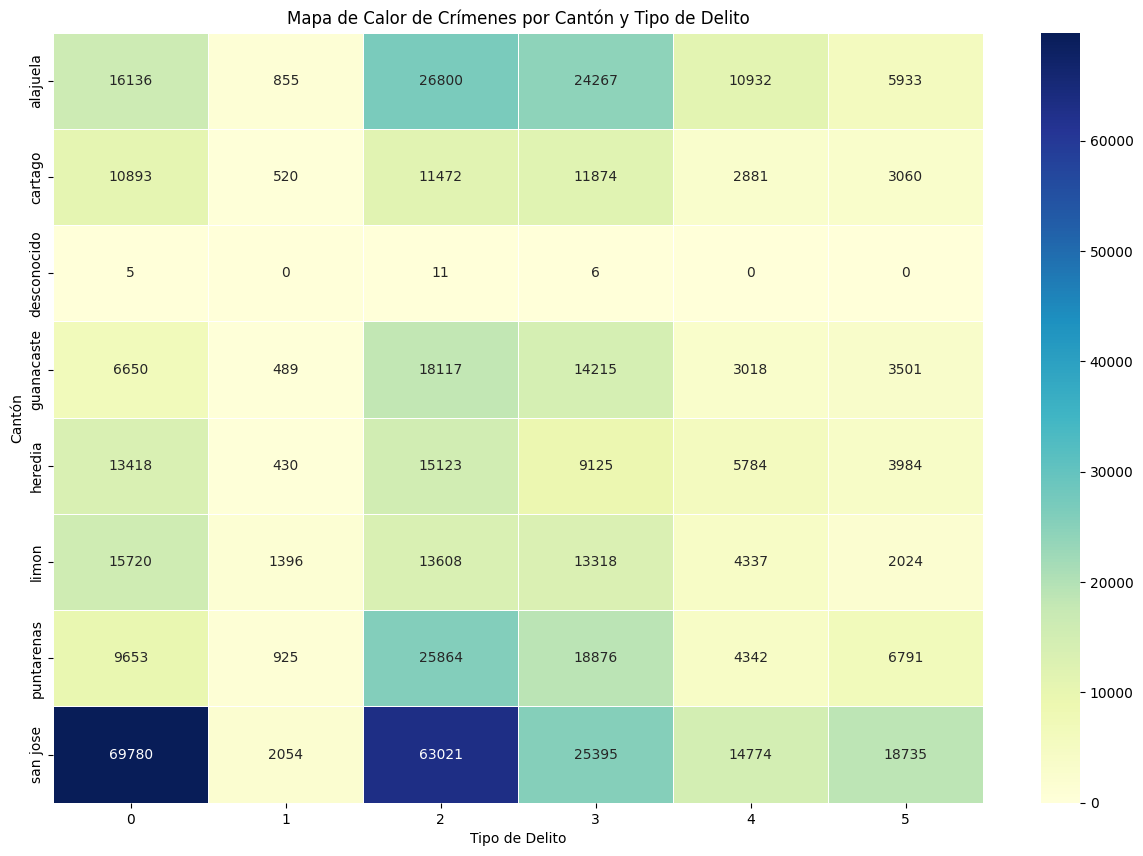

In [ ]:
# Crear una tabla cruzada para contar los crímenes por Cantón y Delito
crimes_canton_delito = pd.crosstab(df_copia_para_trabajar_crimen_weather['canton'], df_copia_para_trabajar_crimen_weather['Delito'])

plt.figure(figsize=(15, 10))
sns.heatmap(crimes_canton_delito, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)
plt.title('Mapa de Calor de Crímenes por Cantón y Tipo de Delito')
plt.xlabel('Tipo de Delito')
plt.ylabel('Cantón')
plt.show()

# data visualization

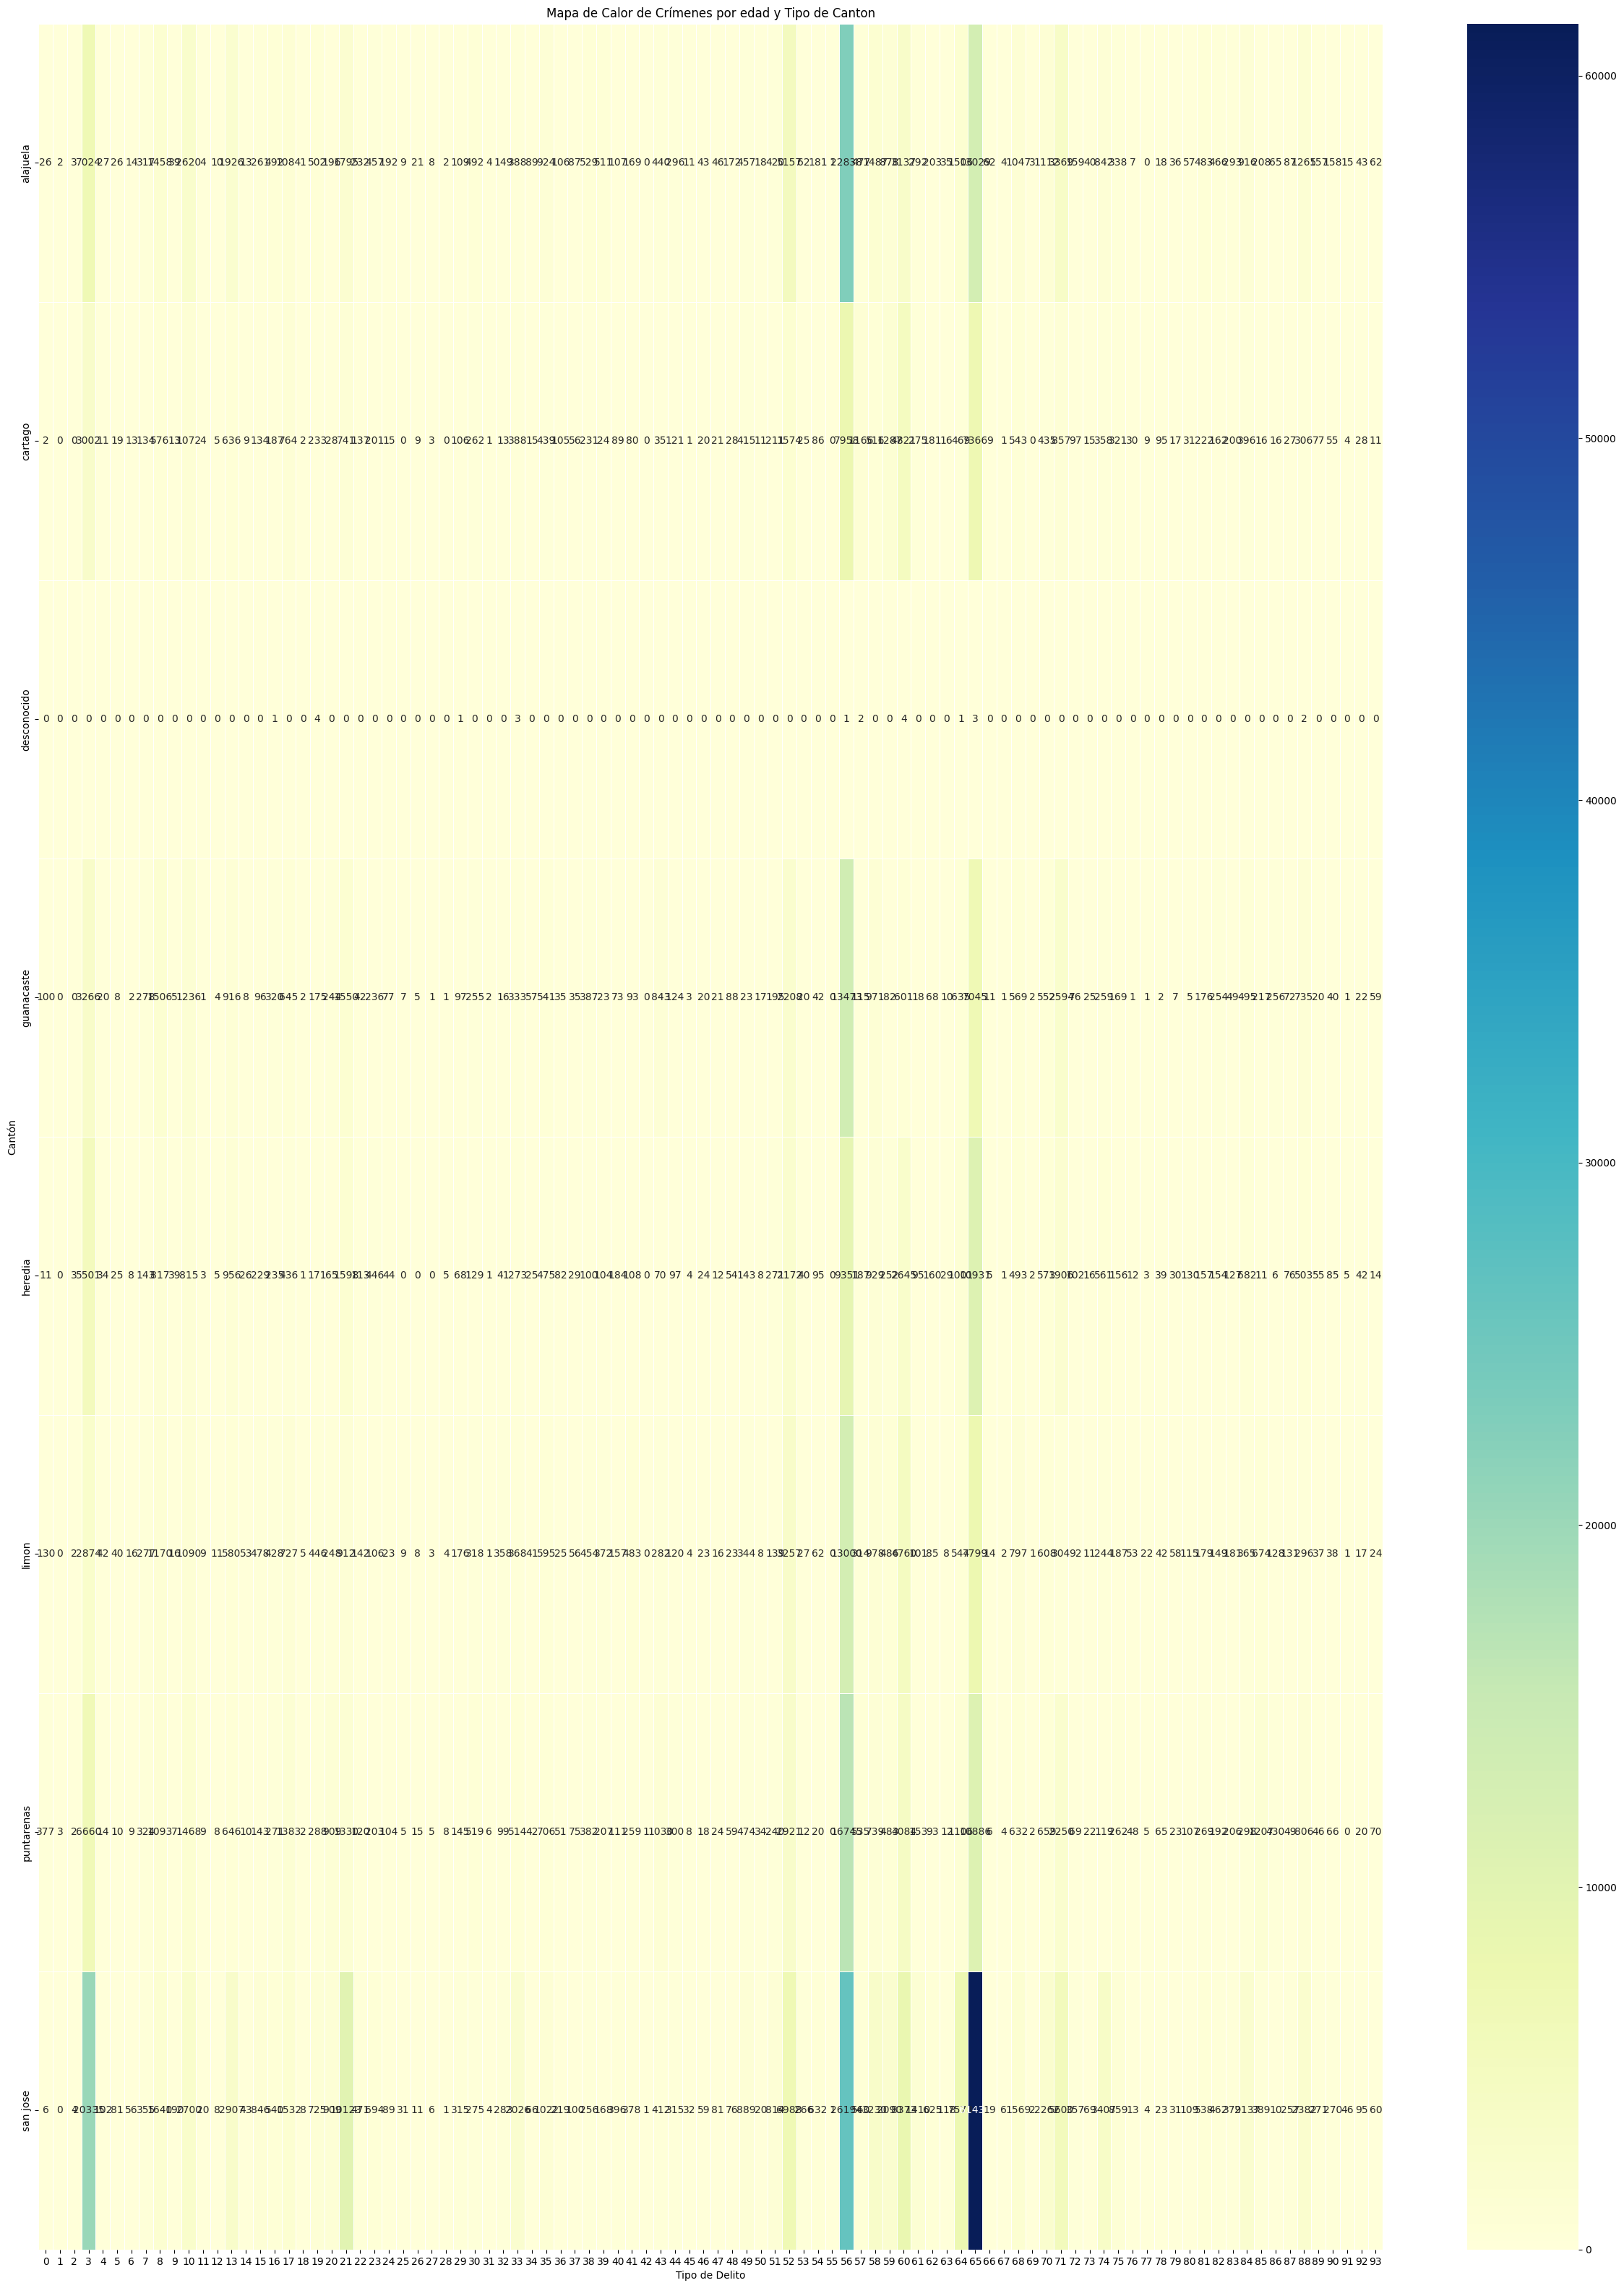

In [ ]:
# Crear una tabla cruzada para contar los crímenes por Cantón y Delito
crimes_canton_delito = pd.crosstab(df_copia_para_trabajar_crimen_weather['canton'], df_copia_para_trabajar_crimen_weather['Edad'])

plt.figure(figsize=(30, 40))
sns.heatmap(crimes_canton_delito, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)
plt.title('Mapa de Calor de Crímenes por edad y Tipo de Canton')
plt.xlabel('Tipo de Delito')
plt.ylabel('Cantón')
plt.show()

# Data visualization
Mapa de Calor de Crímenes por Hora del Día y Día de la Semana'

/tmp/ipython-input-3001173414.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  crimes_por_hora_dia = df_copia_para_trabajar_crimen_weather.groupby(['hora', 'dia_semana']).size().unstack(fill_value=0)


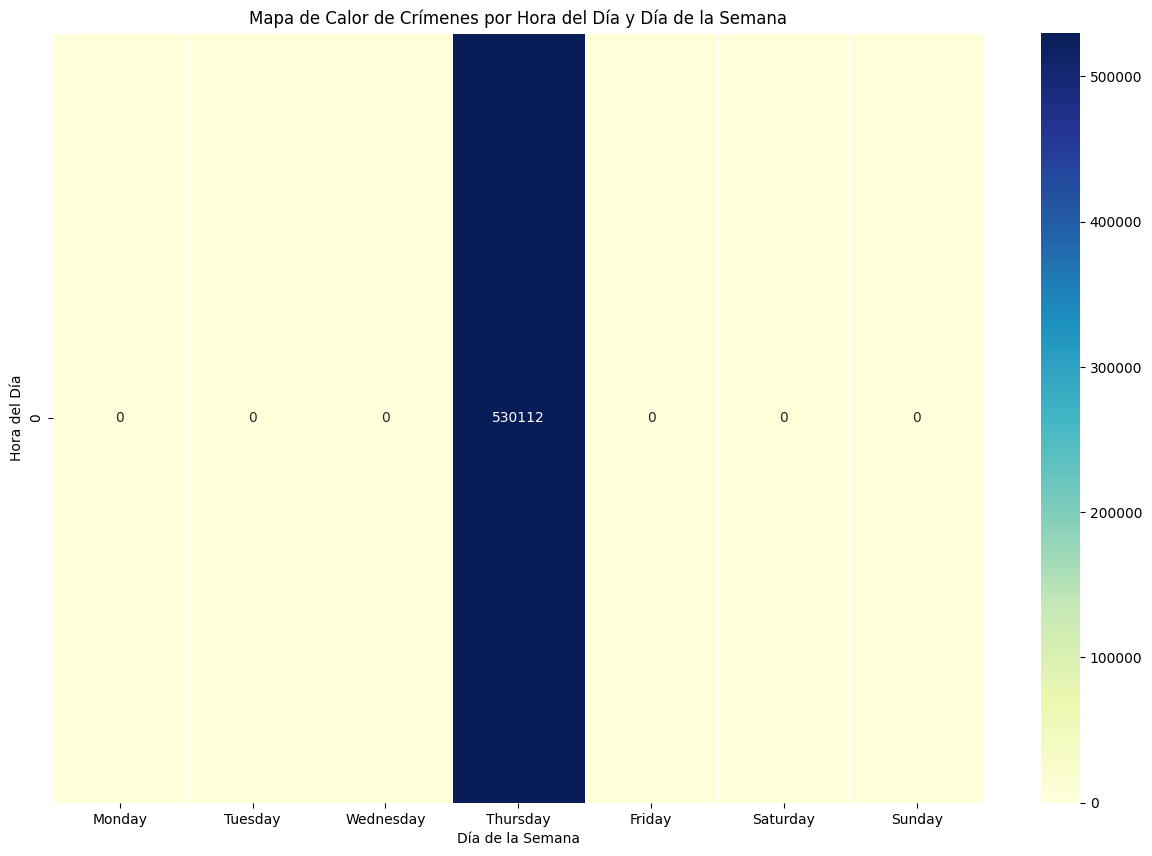

In [ ]:
# Asegurarse de que la columna 'Date' sea de tipo datetime
df_copia_para_trabajar_crimen_weather['date'] = pd.to_datetime(df_copia_para_trabajar_crimen_weather['date'])

# Extraer el día de la semana y la hora
df_copia_para_trabajar_crimen_weather['dia_semana'] = df_copia_para_trabajar_crimen_weather['date'].dt.day_name()
df_copia_para_trabajar_crimen_weather['hora'] = df_copia_para_trabajar_crimen_weather['date'].dt.hour

# Ordenar los días de la semana para el gráfico
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_copia_para_trabajar_crimen_weather['dia_semana'] = pd.Categorical(df_copia_para_trabajar_crimen_weather['dia_semana'], categories=orden_dias, ordered=True)

# Crear una tabla pivote para el conteo de crímenes
crimes_por_hora_dia = df_copia_para_trabajar_crimen_weather.groupby(['hora', 'dia_semana']).size().unstack(fill_value=0)

plt.figure(figsize=(15, 10))
sns.heatmap(crimes_por_hora_dia, cmap='YlGnBu', annot=True, fmt='d', linewidths=.5)
plt.title('Mapa de Calor de Crímenes por Hora del Día y Día de la Semana')
plt.xlabel('Día de la Semana')
plt.ylabel('Hora del Día')
plt.show()

# Data visualization
Precipitación Total del Día (mm)

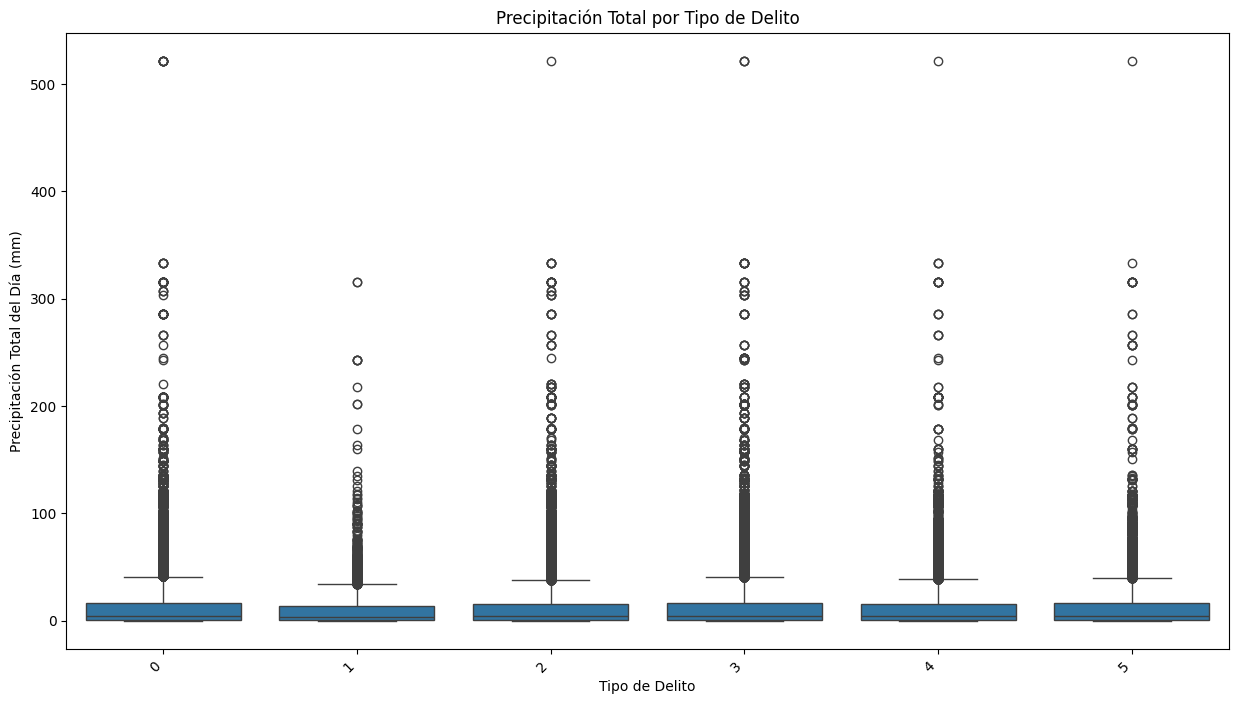

In [ ]:
# Analizar la relación entre la Precipitación y el Tipo de Delito
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_copia_para_trabajar_crimen_weather, x='Delito', y='PRECIP_TOTAL_DAY_MM')
plt.title('Precipitación Total por Tipo de Delito')
plt.xlabel('Tipo de Delito')
plt.ylabel('Precipitación Total del Día (mm)')
plt.xticks(rotation=45, ha='right')
plt.show()

# Data visualization
Temperatura max Total por Tipo de Delito

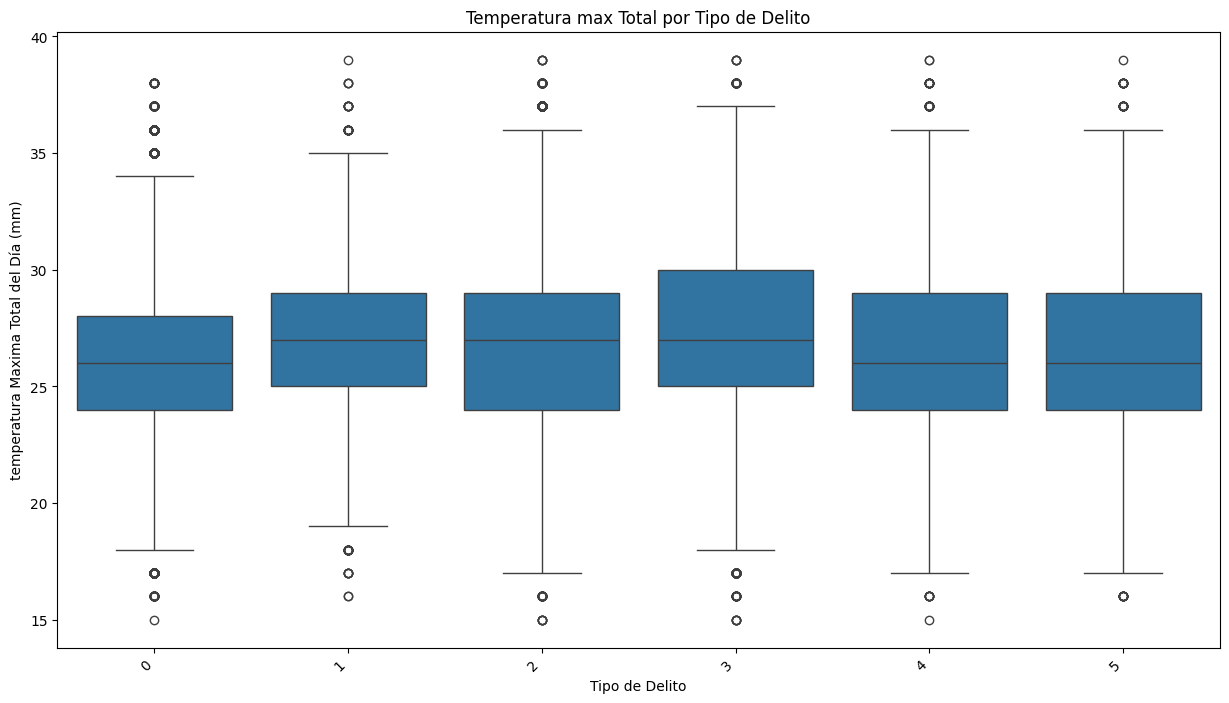

In [ ]:
# Analizar la relación entre la Precipitación y el Tipo de Delito
plt.figure(figsize=(15, 8))
sns.boxplot(data=df_copia_para_trabajar_crimen_weather, x='Delito', y='MAX_TEMPERATURE_C')
plt.title('Temperatura max Total por Tipo de Delito')
plt.xlabel('Tipo de Delito')
plt.ylabel('temperatura Maxima Total del Día (mm)')
plt.xticks(rotation=45, ha='right')
plt.show()


# Data visualization
Distribución de la Edad de las Víctimas

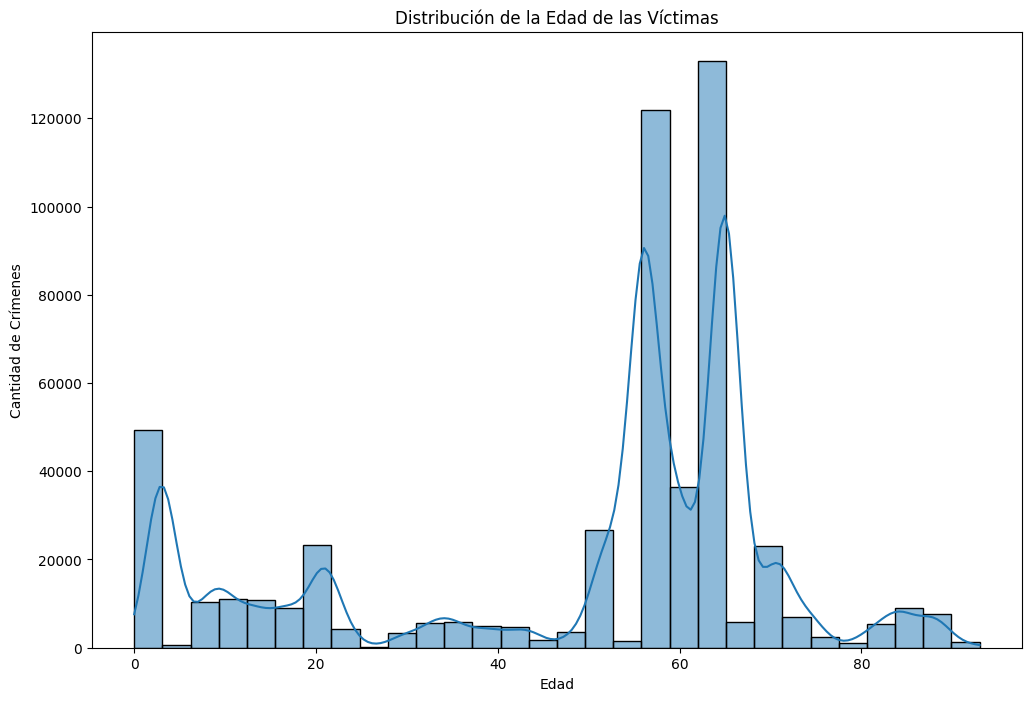

In [ ]:
# Histograma de la distribución de la edad
plt.figure(figsize=(12, 8))
sns.histplot(data=df_copia_para_trabajar_crimen_weather, x='Edad', bins=30, kde=True)
plt.title('Distribución de la Edad de las Víctimas')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Crímenes')
plt.show()

# Data visualization
Crímenes por Tipo de Víctima y Género

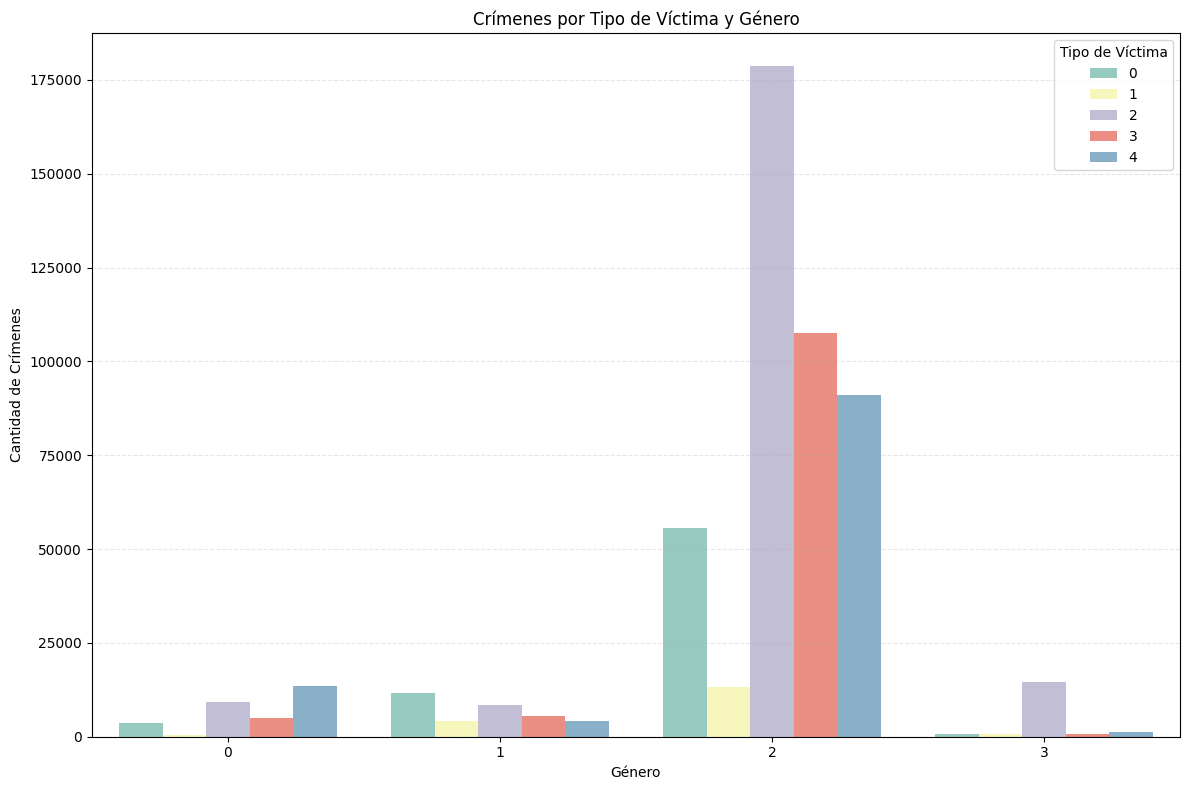

In [ ]:
plt.figure(figsize=(12, 8))
sns.countplot(data=df_copia_para_trabajar_crimen_weather, x='Sexo', hue='SubVictima', palette='Set3')
plt.title('Crímenes por Tipo de Víctima y Género')
plt.xlabel('Género')
plt.ylabel('Cantidad de Crímenes')
plt.legend(title='Tipo de Víctima')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# correlaciones entre crima y clima

# creation of a violence index
based on sub-crimes